<p align="center">
  <img src="https://i0.wp.com/www.tiempodecine.co/web/wp-content/uploads/2015/11/Robert-De-Niro-in-Taxi-Driver-1976.jpg?resize=750%2C375&ssl=1" style="width:100%; max-width:900px; height:180px; object-fit:cover; border-radius:10px;"/>
</p>
<div style="text-align:center;">
  <h1 style="color:#FFD700; display:inline-block; margin:0;">Optimización del Transporte en Nueva York</h1>
  <p>
    <b>Green Taxi | Machine Learning & Data Science | CRISP-DM</b><br>
    <span style="font-size:1.1em;">Preparación de datos para Clustering de Zonas de NYC</span>
  </p>
</div>

# FASE 3: Data Preparation (CRISP-DM)

## Propósito de la Fase de Preparación de Datos

En esta tercera fase del proceso CRISP-DM, nos enfocamos en preparar los datos para aplicar **algoritmos de Clustering (No Supervisado)** con el objetivo de:

### **Problema de Negocio:**
- Algunas zonas tienen alta concentración de viajes en ciertas horas
- Otras zonas permanecen con poca actividad
- Dificulta la distribución eficiente de taxis y vehículos de alquiler

### **Objetivos:**
1. **Agrupar zonas** según volumen de viajes, hora pico y tipo de servicio
2. **Identificar áreas** con alta demanda o saturadas
3. **Optimizar** la asignación de flotas y planificación de estaciones

### **Tareas de esta Fase:**
- Feature Engineering para clustering
- Imputación de valores nulos
- Control de outliers
- Encoding de variables categóricas
- Normalización/Estandarización
- Creación de features agregadas por zona

# Carga de Librerías

In [1]:
# Verifica si las librerías necesarias ya están instaladas
try:
    # Ignorar warnings
    import warnings
    warnings.filterwarnings('ignore')
    
    # Librerías del sistema
    import sys, subprocess
    
    # Importaciones base
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import scipy.stats as stats
    
    # Librerías de sistema de archivos
    import os as os  
    from os import path
    import pickle as pkl
    import joblib
    
    # Librerías de Machine Learning
    from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
    from sklearn.impute import SimpleImputer
    from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
    from sklearn.decomposition import PCA
    from sklearn.metrics import silhouette_score, davies_bouldin_score
    
    print("Dependencias ya instaladas.")

except ImportError:
    print("Dependencias no encontradas. Instalando ahora...")
    
    # Se ejecutan los comandos de instalación
    %pip install --quiet matplotlib
    %pip install --quiet seaborn
    %pip install --quiet joblib
    %pip install --quiet scipy
    %pip install --quiet scikit-learn
    %pip install --quiet pyarrow
    
    print("Instalación completada.")

Dependencias ya instaladas.


# Configuración de Visualización

In [2]:
# Configuración de estilo para gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Configuración de visualización completada.")

Configuración de visualización completada.


# 1. Carga de Datos Procesados

Cargamos los datasets que fueron preparados en las fases anteriores:

In [3]:
print("=" * 60)
print("Cargando datasets...")
print("=" * 60)
# TAXIS (Yellow/Green) - Dataset equilibrado
taxis_df = pd.read_parquet('data/DataUnderstanding_taxis_sample.parquet')
print(f"✓ Taxis cargados: {len(taxis_df):,} registros")

# FHVHV (Uber/Lyft) - Muestra del 1%
fhvhv_df = pd.read_parquet('data/DataUnderstanding_fhvhv_sample.parquet')
print(f"✓ FHVHV cargados: {len(fhvhv_df):,} registros")

Cargando datasets...
✓ Taxis cargados: 96,410 registros
✓ FHVHV cargados: 548,864 registros
✓ FHVHV cargados: 548,864 registros


# 2. Exploración Inicial de Datos

In [4]:
# Información general del dataset de Taxis
print("=" * 60)
print("INFORMACIÓN DEL DATASET DE TAXIS")
print("=" * 60)
print(f"\nShape: {taxis_df.shape}")
print(f"\nTipos de datos:")
print(taxis_df.dtypes)
print(f"\nSamples de las Primeras 10 filas:")
taxis_df.sample(5)

INFORMACIÓN DEL DATASET DE TAXIS

Shape: (96410, 35)

Tipos de datos:
pickup_datetime          datetime64[us]
pickup_year                       int32
pickup_month                      int32
pickup_day                        int32
pickup_hour                       int32
pickup_day_of_week                int32
is_weekend                        int64
time_band                        object
dropoff_datetime         datetime64[us]
trip_duration_min               float64
PULocationID                      int32
DOLocationID                      int32
VendorID                          int32
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
payment_type                    float64
store_and_fwd_flag               object
trip_type                       float64
fare_amount                     float64
total_amount                    float64
extra                           float64
mta_tax                         float64
tip_amount

,pickup_datetime,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_day_of_week,is_weekend,time_band,dropoff_datetime,trip_duration_min,PULocationID,DOLocationID,VendorID,passenger_count,trip_distance,RatecodeID,payment_type,store_and_fwd_flag,trip_type,fare_amount,total_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,cbd_congestion_fee,taxi_color,taxi_color_ini,is_color,dropoff_hour,pickup_band,dropoff_band,day_type
17467,2025-07-24 11:41:27,2025,7,24,11,3,0,OP_day,2025-07-24 11:53:10,11.720,74,166,2,1.000,1.560,1.000,1.000,N,1.000,12.100,17.000,0.000,0.500,3.400,0.000,1.000,0.000,0.000,green,G,0,11,OP_day,OP_day,Laborable
45667,2025-07-27 02:19:49,2025,7,27,2,6,1,Early_Morning,2025-07-27 02:21:41,1.870,70,70,2,1.000,0.010,5.000,2.000,N,2.000,90.000,91.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,green,G,0,2,Early_Morning,Early_Morning,Fin de semana
92685,2025-07-28 00:07:21,2025,7,28,0,0,0,Early_Morning,2025-07-28 00:21:48,14.450,145,223,2,NaN,3.100,NaN,0.000,None,NaN,17.440,18.940,0.000,0.500,0.000,0.000,1.000,NaN,0.000,yellow,Y,1,0,Early_Morning,Early_Morning,Laborable
34721,2025-07-20 21:09:00,2025,7,20,21,6,1,OP_night,2025-07-20 21:37:15,28.250,75,260,2,1.000,7.010,1.000,1.000,N,1.000,33.800,47.760,1.000,0.500,7.960,0.000,1.000,2.750,0.750,green,G,0,21,OP_night,OP_night,Fin de semana
76618,2025-07-30 06:31:27,2025,7,30,6,2,0,AM_Peak,2025-07-30 06:35:26,3.980,48,68,2,1.000,1.100,1.000,1.000,N,NaN,7.200,14.940,0.000,0.500,2.990,0.000,1.000,2.500,0.750,yellow,Y,1,6,AM_Peak,AM_Peak,Laborable


In [5]:
# Análisis de valores nulos
print("=" * 60)
print("ANÁLISIS DE VALORES NULOS - TAXIS")
print("=" * 60)

missing_taxis = taxis_df.isnull().sum()
missing_pct_taxis = (missing_taxis / len(taxis_df)) * 100
missing_df_taxis = pd.DataFrame({
    'Columna': missing_taxis.index,
    'Valores Nulos': missing_taxis.values,
    'Porcentaje': missing_pct_taxis.values
})

# Formatear porcentaje a 2 decimales fijos
missing_df_taxis['Porcentaje'] = missing_df_taxis['Porcentaje'].apply(lambda x: f"{x:.2f}")

# Filtrar y ordenar
missing_df_taxis = missing_df_taxis[missing_df_taxis['Valores Nulos'] > 0].sort_values('Valores Nulos', ascending=False)

if len(missing_df_taxis) > 0:
    print(missing_df_taxis.to_string(index=False))
else:
    print("✓ No hay valores nulos en el dataset de Taxis")

ANÁLISIS DE VALORES NULOS - TAXIS
             Columna  Valores Nulos Porcentaje
           trip_type          53390      55.38
     passenger_count          18068      18.74
          RatecodeID          18068      18.74
  store_and_fwd_flag          18068      18.74
congestion_surcharge          18068      18.74
        payment_type           5185       5.38


# 3. Feature Engineering para Clustering

## 3.1 Agregación por Zona (LocationID)

Para el clustering de zonas, necesitamos agregar los datos a nivel de zona (PULocationID) y crear features que capturen:
- **Volumen de viajes** por zona
- **Patrones temporales** (hora pico, distribución horaria)
- **Tipo de servicio** predominante (Yellow/Green)
- **Características de los viajes** (distancia promedio, duración, tarifas)

In [6]:
print("=" * 60)
print("CREANDO FEATURES AGREGADAS POR ZONA")
print("=" * 60)

# Features temporales ya están creadas en taxis_df, verificar si existen
print("Verificando features temporales...")
if 'pickup_hour' not in taxis_df.columns:
    taxis_df['pickup_hour'] = taxis_df['pickup_datetime'].dt.hour
if 'pickup_day_of_week' not in taxis_df.columns:
    taxis_df['pickup_day_of_week'] = taxis_df['pickup_datetime'].dt.dayofweek

print("✓ Features temporales verificadas")

# Agregación por zona de pickup (PULocationID) usando columnas de TAXIS
zone_features = taxis_df.groupby('PULocationID').agg({
    # Volumen de viajes
    'VendorID': 'count',  # Total de viajes
    
    # Características temporales
    'pickup_hour': ['mean', 'std'],  # Hora promedio y variabilidad
    'pickup_day_of_week': 'mean',  # Día de la semana promedio
    
    # Características del viaje
    'trip_distance': ['mean', 'std', 'median'],  # Distancia
    'trip_duration_min': 'mean',  # Duración promedio en minutos
    
    # Características financieras
    'fare_amount': ['mean', 'std'],  # Tarifa base
    'total_amount': ['mean', 'std'],  # Monto total
    'tip_amount': 'mean',  # Propinas
    'tolls_amount': 'mean',  # Peajes
    
    # Tipo de servicio (taxi color)
    'is_color': 'mean',  # Proporción de yellow vs green taxis
}).reset_index()

# Aplanar nombres de columnas multinivel
zone_features.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                        for col in zone_features.columns.values]

# Renombrar columnas con nombres más descriptivos
zone_features.columns = [
    'zone_id',
    'total_trips',
    'avg_pickup_hour',
    'std_pickup_hour',
    'avg_day_of_week',
    'avg_trip_distance',
    'std_trip_distance',
    'median_trip_distance',
    'avg_trip_duration',
    'avg_fare',
    'std_fare',
    'avg_total_amount',
    'std_total_amount',
    'avg_tip',
    'avg_tolls',
    'avg_color_taxi'
]

print(f"✓ Features agregadas creadas: {zone_features.shape}")
print(f"\nPrimeras filas:")
zone_features.sample(5)

CREANDO FEATURES AGREGADAS POR ZONA
Verificando features temporales...
✓ Features temporales verificadas
✓ Features agregadas creadas: (248, 16)

Primeras filas:


,zone_id,total_trips,avg_pickup_hour,std_pickup_hour,avg_day_of_week,avg_trip_distance,std_trip_distance,median_trip_distance,avg_trip_duration,avg_fare,std_fare,avg_total_amount,std_total_amount,avg_tip,avg_tolls,avg_color_taxi
116,130,1696,14.364,6.714,2.999,5.226,5.062,3.260,21.000,26.810,23.407,33.332,26.206,3.220,0.327,0.047
86,92,428,13.673,6.649,2.993,47.381,904.726,2.070,28.475,30.478,44.436,35.950,45.843,2.326,0.216,0.056
35,39,140,11.357,4.877,2.707,4.781,4.505,3.240,24.014,14.413,18.334,25.692,18.673,0.347,0.446,0.436
115,129,707,12.139,6.698,3.024,3.358,4.278,2.190,21.522,19.798,18.408,25.025,20.290,1.693,0.402,0.091
33,37,144,11.889,7.446,3.646,5.407,4.432,4.305,27.959,20.639,16.126,29.817,15.714,0.917,0.879,0.653


## 3.2 Identificación de Horas Pico por Zona

In [7]:
# Análisis de distribución horaria por zona
print("Analizando patrones de hora pico por zona...")

# Crear tabla de contingencia: zona x hora
zone_hour_matrix = pd.crosstab(
    taxis_df['PULocationID'],
    taxis_df['pickup_hour']
)

# Identificar hora pico (hora con más viajes) por zona
peak_hours = zone_hour_matrix.idxmax(axis=1).reset_index()
peak_hours.columns = ['zone_id', 'peak_hour']

# Calcular concentración en hora pico (% de viajes en hora pico)
max_trips_per_hour = zone_hour_matrix.max(axis=1)
total_trips_per_zone = zone_hour_matrix.sum(axis=1)
peak_concentration = (max_trips_per_hour / total_trips_per_zone * 100).reset_index()
peak_concentration.columns = ['zone_id', 'peak_hour_concentration_pct']

# Merge con zone_features
zone_features = zone_features.merge(peak_hours, on='zone_id', how='left')
zone_features = zone_features.merge(peak_concentration, on='zone_id', how='left')

print(f"✓ Features de hora pico agregadas")
print(f"\nEstadísticas de concentración en hora pico:")
print(zone_features['peak_hour_concentration_pct'].describe())

Analizando patrones de hora pico por zona...
✓ Features de hora pico agregadas

Estadísticas de concentración en hora pico:
count   248.000
mean     18.381
std      16.728
min       6.082
25%       9.736
50%      13.841
75%      19.286
max     100.000
Name: peak_hour_concentration_pct, dtype: float64
✓ Features de hora pico agregadas

Estadísticas de concentración en hora pico:
count   248.000
mean     18.381
std      16.728
min       6.082
25%       9.736
50%      13.841
75%      19.286
max     100.000
Name: peak_hour_concentration_pct, dtype: float64


## 3.3 Distribución por Bandas Horarias

In [8]:
# Calcular proporción de viajes por banda horaria
print("Calculando distribución por bandas horarias...")

# Crear función para clasificar horas en bandas
def get_time_band(hour):
    if 6 <= hour < 10:
        return 'AM_Peak'
    elif 10 <= hour < 16:
        return 'OP_day'
    elif 16 <= hour < 20:
        return 'PM_Peak'
    elif 20 <= hour < 24:
        return 'OP_night'
    else:
        return 'Early_Morning'

# Aplicar clasificación
taxis_df['time_band'] = taxis_df['pickup_hour'].apply(get_time_band)

# Tabla de contingencia: zona x banda horaria
zone_timeband_matrix = pd.crosstab(
    taxis_df['PULocationID'],
    taxis_df['time_band'],
    normalize='index'  # Normalizar por fila (zona)
) * 100  # Convertir a porcentaje

# Renombrar columnas
zone_timeband_matrix.columns = [f'pct_{col}' for col in zone_timeband_matrix.columns]
zone_timeband_matrix = zone_timeband_matrix.reset_index()
zone_timeband_matrix.rename(columns={'PULocationID': 'zone_id'}, inplace=True)

# Merge con zone_features
zone_features = zone_features.merge(zone_timeband_matrix, on='zone_id', how='left')

print(f"✓ Features de bandas horarias agregadas")
print(f"\nColumnas actuales: {list(zone_features.columns)}")
print(f"\nShape final: {zone_features.shape}")

Calculando distribución por bandas horarias...
✓ Features de bandas horarias agregadas

Columnas actuales: ['zone_id', 'total_trips', 'avg_pickup_hour', 'std_pickup_hour', 'avg_day_of_week', 'avg_trip_distance', 'std_trip_distance', 'median_trip_distance', 'avg_trip_duration', 'avg_fare', 'std_fare', 'avg_total_amount', 'std_total_amount', 'avg_tip', 'avg_tolls', 'avg_color_taxi', 'peak_hour', 'peak_hour_concentration_pct', 'pct_AM_Peak', 'pct_Early_Morning', 'pct_OP_day', 'pct_OP_night', 'pct_PM_Peak']

Shape final: (248, 23)
✓ Features de bandas horarias agregadas

Columnas actuales: ['zone_id', 'total_trips', 'avg_pickup_hour', 'std_pickup_hour', 'avg_day_of_week', 'avg_trip_distance', 'std_trip_distance', 'median_trip_distance', 'avg_trip_duration', 'avg_fare', 'std_fare', 'avg_total_amount', 'std_total_amount', 'avg_tip', 'avg_tolls', 'avg_color_taxi', 'peak_hour', 'peak_hour_concentration_pct', 'pct_AM_Peak', 'pct_Early_Morning', 'pct_OP_day', 'pct_OP_night', 'pct_PM_Peak']

Shap

## 3.4 Patrones de Fin de Semana vs Días Laborales

In [9]:
# Calcular proporción de viajes en fin de semana
print("Analizando patrones de fin de semana...")

# Crear indicador de fin de semana
taxis_df['is_weekend'] = (taxis_df['pickup_day_of_week'] >= 5).astype(int)

# Calcular % de viajes en fin de semana por zona
weekend_pct = taxis_df.groupby('PULocationID')['is_weekend'].mean() * 100
weekend_pct = weekend_pct.reset_index()
weekend_pct.columns = ['zone_id', 'pct_weekend_trips']

# Merge con zone_features
zone_features = zone_features.merge(weekend_pct, on='zone_id', how='left')

print(f"✓ Feature de fin de semana agregada")
print(f"\nDistribución de viajes en fin de semana:")
print(zone_features['pct_weekend_trips'].describe())

Analizando patrones de fin de semana...
✓ Feature de fin de semana agregada

Distribución de viajes en fin de semana:
count   248.000
mean     26.081
std      15.013
min       0.000
25%      18.777
50%      24.780
75%      30.132
max     100.000
Name: pct_weekend_trips, dtype: float64


## 3.5 Clasificación de Nivel de Demanda

Creamos una clasificación inicial de zonas por nivel de demanda basado en el volumen de viajes:

In [10]:
# Clasificar zonas por nivel de demanda usando cuartiles
print("Clasificando zonas por nivel de demanda...")

# Calcular cuartiles
q1 = zone_features['total_trips'].quantile(0.33)
q2 = zone_features['total_trips'].quantile(0.67)

def classify_demand(trips):
    if trips < q1:
        return 'Baja'
    elif trips < q2:
        return 'Media'
    else:
        return 'Alta'

zone_features['demand_level'] = zone_features['total_trips'].apply(classify_demand)

# Mostrar distribución
print("\nDistribución de zonas por nivel de demanda:")
print(zone_features['demand_level'].value_counts())
print("\nPorcentaje:")
print(zone_features['demand_level'].value_counts(normalize=True) * 100)

Clasificando zonas por nivel de demanda...

Distribución de zonas por nivel de demanda:
demand_level
Media    87
Alta     82
Baja     79
Name: count, dtype: int64

Porcentaje:
demand_level
Media   35.081
Alta    33.065
Baja    31.855
Name: proportion, dtype: float64


# 4. Estadísticas Descriptivas de Features

In [11]:
# Estadísticas descriptivas de todas las features numéricas
print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS DE FEATURES")
print("=" * 60)

# Seleccionar solo columnas numéricas
numeric_cols = zone_features.select_dtypes(include=[np.number]).columns
print(f"\nTotal de features numéricas: {len(numeric_cols)}")
print("\nEstadísticas:")
zone_features[numeric_cols].describe().T

ESTADÍSTICAS DESCRIPTIVAS DE FEATURES

Total de features numéricas: 24

Estadísticas:


,count,mean,std,min,25%,50%,75%,max
zone_id,248.000,134.677,77.032,1.000,66.750,137.500,201.250,265.000
total_trips,248.000,388.750,1011.539,1.000,21.750,62.000,392.500,12277.000
avg_pickup_hour,248.000,12.803,2.243,6.000,11.421,12.834,14.312,20.226
std_pickup_hour,241.000,5.672,1.637,0.707,4.906,5.692,6.423,15.556
avg_day_of_week,248.000,2.931,0.644,0.500,2.641,2.889,3.144,6.000
avg_trip_distance,248.000,23.700,166.452,0.311,3.336,4.985,7.525,2350.036
std_trip_distance,241.000,213.730,1392.403,0.205,3.246,4.441,6.040,15548.776
median_trip_distance,248.000,4.518,3.533,0.000,1.989,3.515,5.446,26.190
avg_trip_duration,248.000,24.316,11.453,1.253,16.395,22.411,29.169,106.771
avg_fare,248.000,20.730,11.488,-6.700,14.364,17.134,22.580,74.370


### Features clave para analizar (verificadas que existen en zone_features)
key_features = [
    'zone_id',
    'total_trips',
    'avg_pickup_hour',
    'std_pickup_hour',
    'avg_day_of_week',
    'avg_trip_distance',
    'std_trip_distance',
    'median_trip_distance',
    'avg_trip_duration',
    'avg_fare',
    'std_fare',
    'avg_total_amount',
    'std_total_amount',
    'avg_tip',
    'avg_tolls',
    'avg_color_taxi',
    'peak_hour',
    'peak_hour_concentration_pct',
    'pct_AM_Peak',
    'pct_Early_Morning',
    'pct_OP_day',
    'pct_OP_night',
    'pct_PM_Peak',
    'pct_weekend_trips',
    'demand_level'
]


# 5. Detección y Tratamiento de Outliers

## 5.1 Visualización de Outliers

Analizando 23 características numéricas para outliers
Características: ['total_trips', 'avg_pickup_hour', 'std_pickup_hour', 'avg_day_of_week', 'avg_trip_distance', 'std_trip_distance', 'median_trip_distance', 'avg_trip_duration', 'avg_fare', 'std_fare', 'avg_total_amount', 'std_total_amount', 'avg_tip', 'avg_tolls', 'avg_color_taxi', 'peak_hour', 'peak_hour_concentration_pct', 'pct_AM_Peak', 'pct_Early_Morning', 'pct_OP_day', 'pct_OP_night', 'pct_PM_Peak', 'pct_weekend_trips']


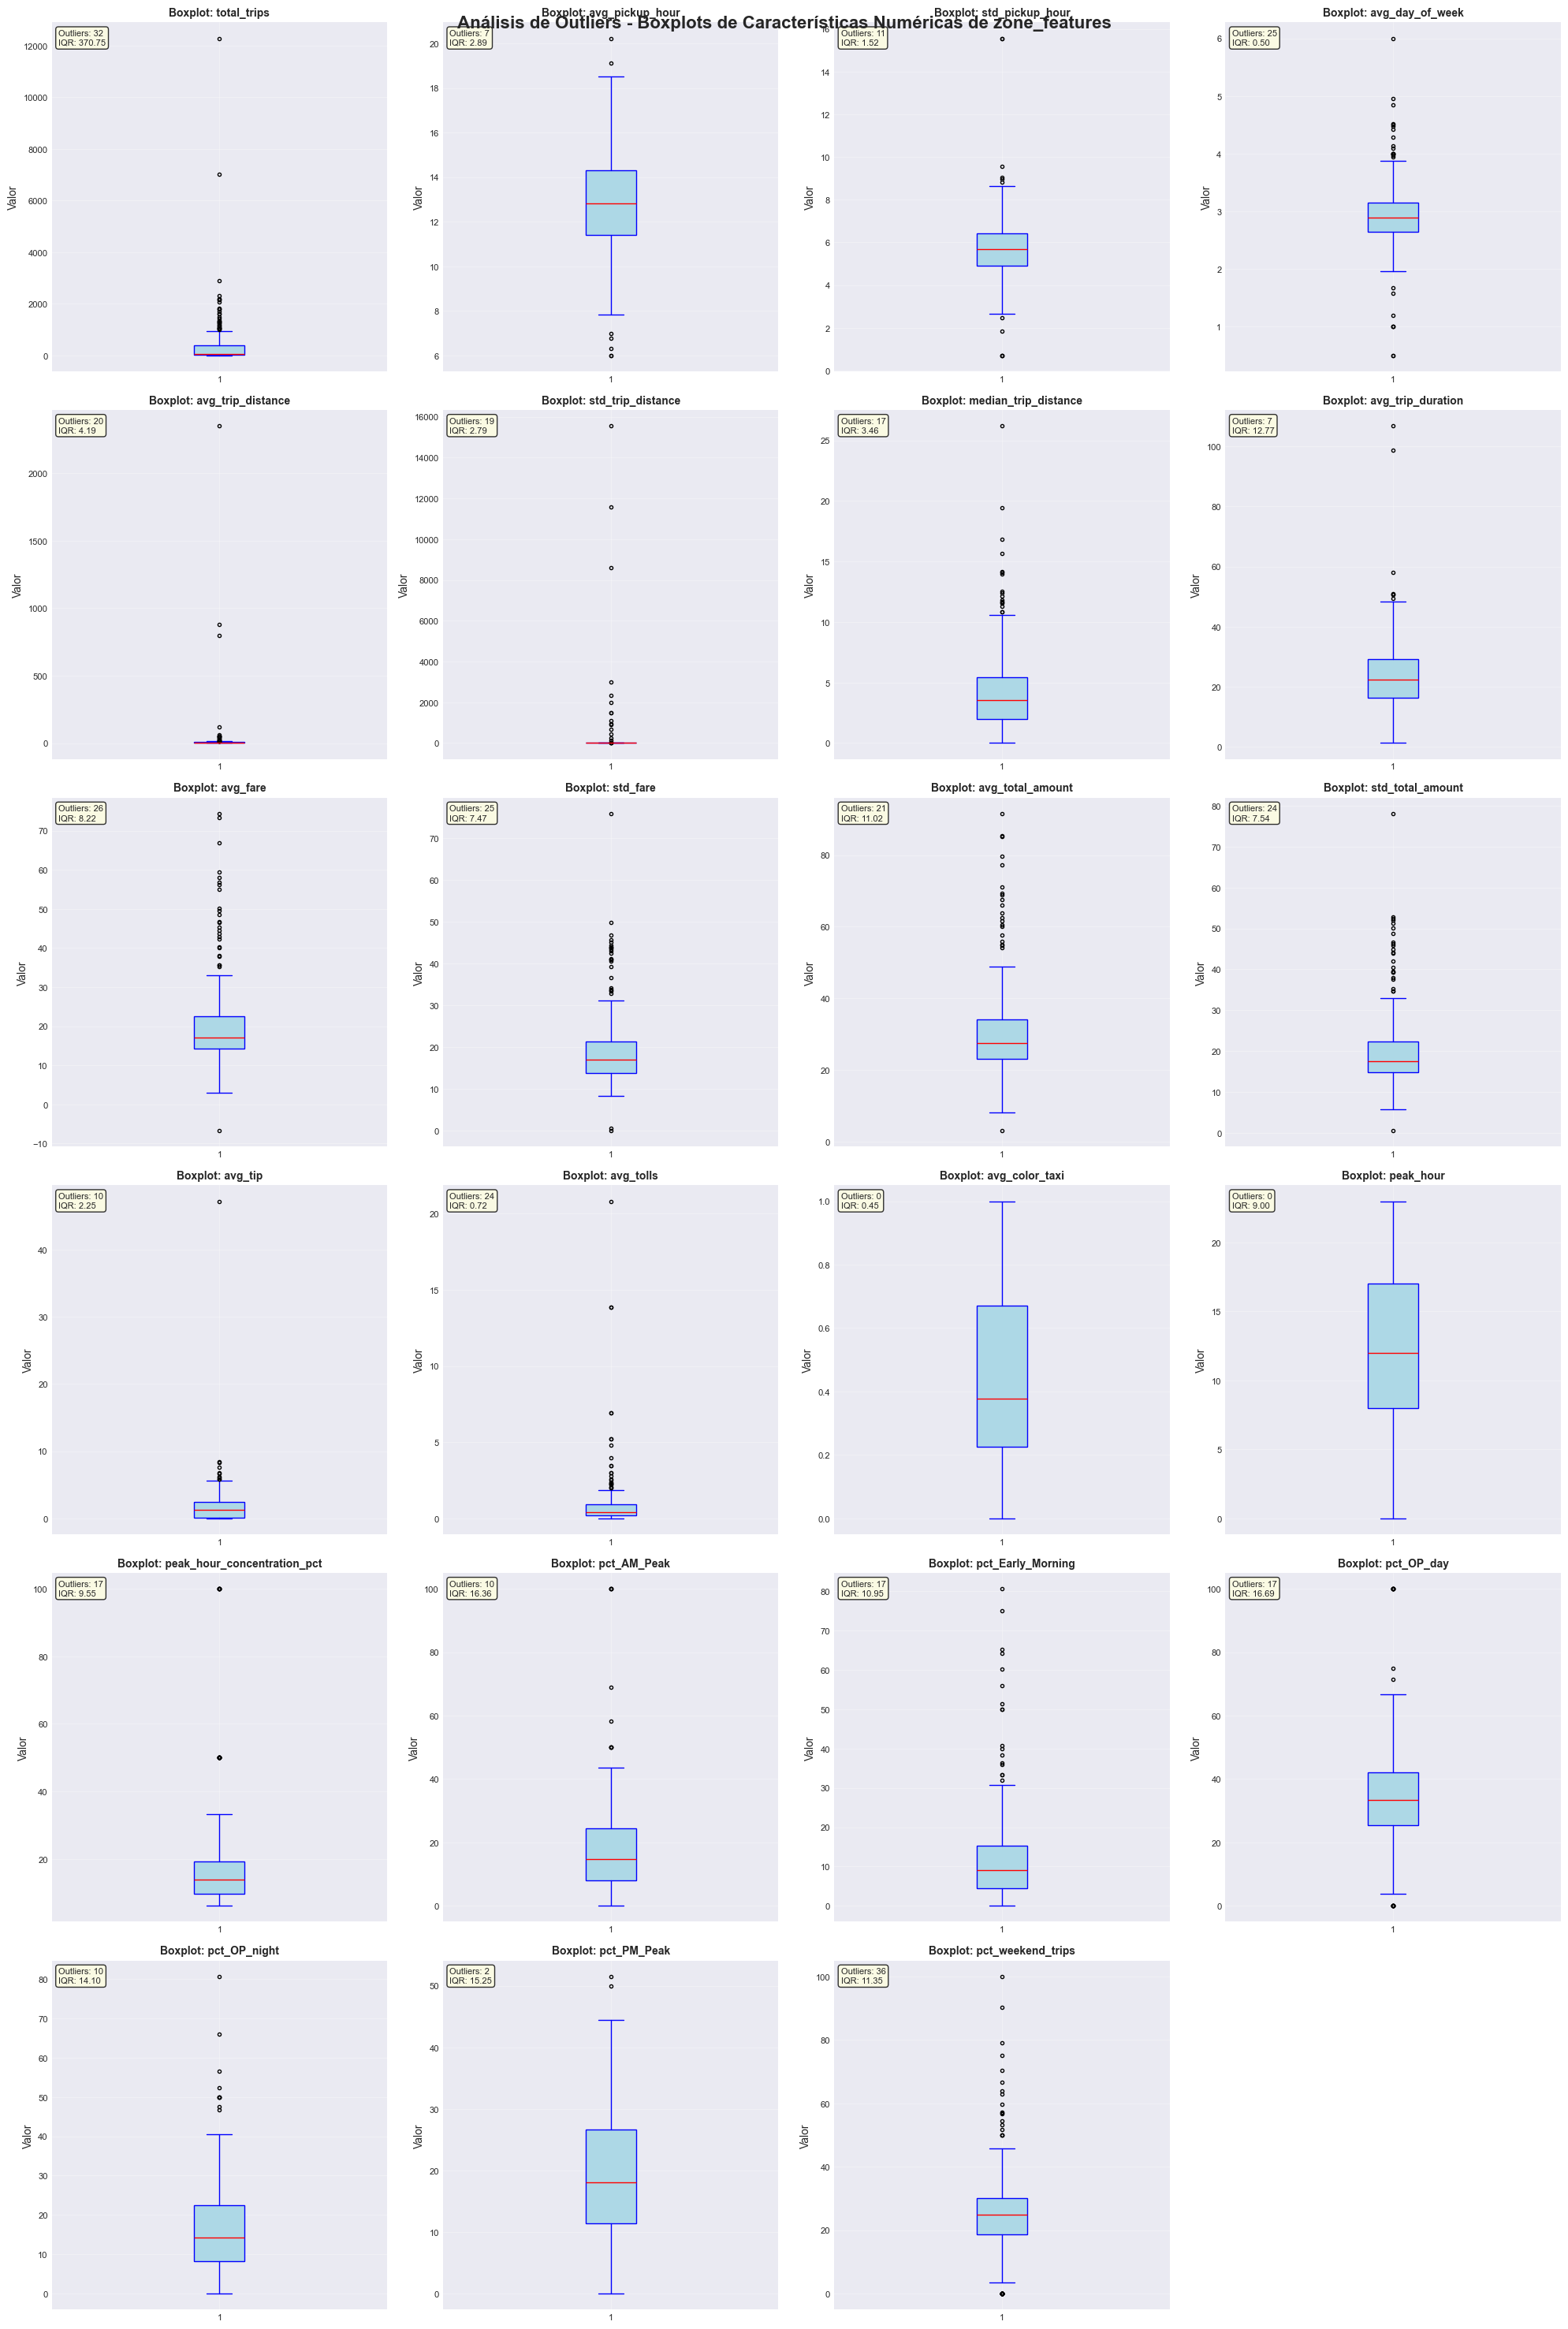

✓ Análisis de outliers completado
Total de características analizadas: 23
Nota: Los outliers se identifican usando el método IQR (1.5 * IQR)


In [12]:
# Realizar análisis de outliers con boxplot de todas las características del dataset "zone_features"
# Seleccionar solo columnas numéricas para boxplots (excluir 'zone_id' y 'demand_level' que son categóricas/ID)
numeric_features = zone_features.select_dtypes(include=[np.number]).columns.tolist()
if 'zone_id' in numeric_features:
	numeric_features.remove('zone_id')  # Excluir ID para análisis de outliers

print(f"Analizando {len(numeric_features)} características numéricas para outliers")
print(f"Características: {numeric_features}")

# Crear grid de 4 columnas x 6 filas (24 subplots)
n_cols = 4
n_rows = 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 30))
axes = axes.ravel()  # Aplanar para iterar fácilmente

# Crear boxplots para cada característica numérica
for idx, feature in enumerate(numeric_features):
	if idx < len(axes):  # Asegurar que no excedamos el número de subplots
		data = zone_features[feature].dropna()  # Eliminar NaN para boxplot
		if len(data) > 0:
			axes[idx].boxplot(data, vert=True, patch_artist=True, 
							boxprops=dict(facecolor='lightblue', color='blue'),
							medianprops=dict(color='red'),
							whiskerprops=dict(color='blue'),
							capprops=dict(color='blue'),
							flierprops=dict(marker='o', color='red', markersize=3))
			axes[idx].set_title(f'Boxplot: {feature}', fontsize=10, fontweight='bold')
			axes[idx].set_ylabel('Valor')
			axes[idx].grid(True, alpha=0.3)
			axes[idx].tick_params(axis='x', labelsize=8)
			axes[idx].tick_params(axis='y', labelsize=8)
			
			# Agregar estadísticas básicas
			q1 = data.quantile(0.25)
			q3 = data.quantile(0.75)
			iqr = q3 - q1
			outliers = ((data < (q1 - 1.5 * iqr)) | (data > (q3 + 1.5 * iqr))).sum()
			axes[idx].text(0.02, 0.98, f'Outliers: {outliers}\nIQR: {iqr:.2f}', 
						  transform=axes[idx].transAxes, va='top', fontsize=8,
						  bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
		else:
			axes[idx].text(0.5, 0.5, f'No data\nfor {feature}', 
						  ha='center', va='center', transform=axes[idx].transAxes)
			axes[idx].set_title(f'No data: {feature}', fontsize=10, color='orange')

# Ocultar subplots vacíos si hay menos features que subplots
for idx in range(len(numeric_features), len(axes)):
	axes[idx].set_visible(False)

plt.suptitle('Análisis de Outliers - Boxplots de Características Numéricas de zone_features', 
			 fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("✓ Análisis de outliers completado")
print(f"Total de características analizadas: {len(numeric_features)}")
print("Nota: Los outliers se identifican usando el método IQR (1.5 * IQR)")

In [13]:
# Función para detectar outliers usando IQR
def detect_outliers_iqr(df, column, factor=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

# Detectar outliers en features clave
print("Detectando outliers...\n")

if 'numeric_key_features' in globals():
    features_to_evaluate = numeric_key_features
elif 'key_features' in globals():
    features_to_evaluate = [
        feature for feature in key_features
        if feature in zone_features.columns and pd.api.types.is_numeric_dtype(zone_features[feature])
    ]
else:
    features_to_evaluate = zone_features.select_dtypes(include=[np.number]).columns.tolist()

outlier_summary = []

for feature in features_to_evaluate:
    outliers, lower, upper = detect_outliers_iqr(zone_features, feature)
    pct_outliers = (len(outliers) / len(zone_features)) * 100
    
    outlier_summary.append({
        'Feature': feature,
        'Outliers': len(outliers),
        'Porcentaje': f"{pct_outliers:.2f}%",
        'Lower Bound': f"{lower:.2f}",
        'Upper Bound': f"{upper:.2f}"
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)


Detectando outliers...

                        Feature  Outliers Porcentaje Lower Bound Upper Bound
0                       zone_id         0      0.00%     -135.00      403.00
1                   total_trips        32     12.90%     -534.38      948.62
2               avg_pickup_hour         7      2.82%        7.09       18.65
3               std_pickup_hour        11      4.44%        2.63        8.70
4               avg_day_of_week        25     10.08%        1.89        3.90
5             avg_trip_distance        20      8.06%       -2.95       13.81
6             std_trip_distance        19      7.66%       -0.95       10.23
7          median_trip_distance        17      6.85%       -3.20       10.63
8             avg_trip_duration         7      2.82%       -2.76       48.33
9                      avg_fare        26     10.48%        2.04       34.90
10                     std_fare        25     10.08%        2.65       32.54
11             avg_total_amount        21      8.47%

## 5.2 Tratamiento de Outliers usando IQR Winsorization 

In [14]:
# Aplicar Winsorization (capear outliers en percentiles 1 y 99)
from scipy.stats.mstats import winsorize
print("=" * 60)
print("Tratamiento de Outliers usando IQR Winsorization ")
print("=" * 60)
# Crear copia del dataframe
zone_features_clean = zone_features.copy()

# Aplicar winsorization a features numéricas (excepto zone_id)
numeric_features = zone_features_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('zone_id')  # No aplicar a ID

for feature in numeric_features:
    if zone_features_clean[feature].notna().sum() > 0:  # Solo si hay datos
        zone_features_clean[feature] = winsorize(
            zone_features_clean[feature].fillna(zone_features_clean[feature].median()),
            limits=[0.01, 0.01]  # Cap  ear en percentiles 1 y 99 (conservador para taxi data)
        )

print("✓ Winsorization aplicada")
print(f"\nShape después de tratamiento: {zone_features_clean.shape}")

Tratamiento de Outliers usando IQR Winsorization 
✓ Winsorization aplicada

Shape después de tratamiento: (248, 25)


In [15]:
# Crear variable del dataset con tratamiento de outliers
zone_outliers_winsorized = zone_features_clean.copy()

print("=" * 60)
print("DATASET CON TRATAMIENTO DE OUTLIERS CREADO")
print("=" * 60)
print(f"Variable: zone_outliers_winsorized ")
print(f"Shape: {zone_outliers_winsorized.shape}")
print(f"Tratamiento aplicado: Winsorization en percentiles 1-99")
print(f"Features numéricas tratadas: {len(numeric_features)}")
print("=" * 60)

DATASET CON TRATAMIENTO DE OUTLIERS CREADO
Variable: zone_outliers_winsorized 
Shape: (248, 25)
Tratamiento aplicado: Winsorization en percentiles 1-99
Features numéricas tratadas: 23


## 5.3 Tratamiento de Outliers usando Isolation Forest

**Ventajas del Isolation Forest sobre IQR:**
- Detecta outliers multivariados (considera todas las features simultáneamente)
- No asume distribución específica de los datos
- Maneja mejor datasets con múltiples features correlacionadas
- Más robusto para clustering al preservar la estructura natural de los datos

In [16]:
from sklearn.ensemble import IsolationForest

print("=" * 60)
print("ESTRATEGIA DEFINITIVA: ISOLATION FOREST")
print("=" * 60)

# Crear copia para comparación
zone_outliers_isolation = zone_features.copy()

# Seleccionar features numéricas para detección de outliers
numeric_features_isolation = zone_outliers_isolation.select_dtypes(include=[np.number]).columns.tolist()
zone_outliers_isolation = zone_outliers_isolation[numeric_features_isolation].copy()

ESTRATEGIA DEFINITIVA: ISOLATION FOREST


In [17]:

# Instanciar y ajustar Isolation Forest
isolation_forest = IsolationForest(
	n_estimators=200,
	contamination=0.10,
	random_state=42,
	n_jobs=-1
)

zone_outliers_isolation = isolation_forest.fit_predict(zone_outliers_isolation)

# -1 = outlier, 1 = normal
n_outliers = (zone_outliers_isolation == -1).sum()
n_normal = (zone_outliers_isolation == 1).sum()
pct_outliers = (n_outliers / len(zone_outliers_isolation)) * 100

print(f"✓ Outliers detectados: {n_outliers} ({pct_outliers:.2f}%)")
print(f"✓ Datos normales: {n_normal} ({100 - pct_outliers:.2f}%)")

✓ Outliers detectados: 25 (10.08%)
✓ Datos normales: 223 (89.92%)


## 5.4 Justificación de la Estrategia Elegida

### **¿Por qué Isolation Forest sobre IQR?**

1. **Detección Multivariada**: IF considera todas las features simultáneamente, mientras que IQR analiza cada variable por separado
2. **No Paramétrico**: No asume distribución específica de los datos
3. **Robusto para Clustering**: Preserva zonas únicas que pueden formar clusters válidos
4. **Contextual**: Detecta anomalías basadas en patrones multidimensionales

### **¿Por qué mantener outliers en lugar de eliminarlos?**

1. **Valor de Negocio**: Zonas outlier pueden ser aeropuertos, estaciones de tren o distritos financieros
2. **Información para Clustering**: Estas zonas especiales pueden formar clusters propios
3. **Flexibilidad**: El flag permite tratarlas especialmente durante el modelado
4. **Preservación de Datos**: No perdemos información valiosa del dataset

## 5.5 Estrategia de Manejo de Valores Nulos 

Después de la detección de outliers, aplicamos una estrategia específica para valores nulos:

In [18]:
print("=" * 60)
print("ESTRATEGIA UNICA DE IMPUTACION: KNN IMPUTER (K=3)")
print("=" * 60)

# Analizar patrones de valores nulos en zone_outliers_winsorized
print("Analizando valores nulos en dataset final...")

# Verificar valores nulos por columna
null_analysis = []
for column in zone_outliers_winsorized.columns:
    null_count = zone_outliers_winsorized[column].isnull().sum()
    null_pct = (null_count / len(zone_outliers_winsorized)) * 100
    
    if null_count > 0:
        null_analysis.append({
            'Columna': column,
            'Valores_Nulos': null_count,
            'Porcentaje': f"{null_pct:.2f}%",
            'Tipo': zone_outliers_winsorized[column].dtype
        })

if null_analysis:
    null_df = pd.DataFrame(null_analysis)
    print("\nColumnas con valores nulos:")
    print(null_df.to_string(index=False))
    
    print(f"\nESTRATEGIA UNICA APLICADA:")
    print("KNN Imputer (k=3) - Zonas con perfil socioeconomico similar")
    print("Predictores: Volumen de viajes (total_trips) y Distancia promedio (avg_trip_distance)")
    print("Justificacion: Zonas similares en volumen y distancia tienen caracteristicas comparables")
    
    # Aplicar KNN Imputer con predictores específicos
    from sklearn.impute import KNNImputer
    
    # Definir predictores principales
    main_predictors = ['total_trips', 'avg_trip_distance']
    
    # Verificar que los predictores existen y no tienen valores nulos
    available_predictors = []
    for predictor in main_predictors:
        if predictor in zone_outliers_winsorized.columns:
            if zone_outliers_winsorized[predictor].isnull().sum() == 0:
                available_predictors.append(predictor)
                print(f"Predictor disponible: {predictor}")
            else:
                # Si un predictor tiene nulos, imputar primero con mediana
                zone_outliers_winsorized[predictor].fillna(
                    zone_outliers_winsorized[predictor].median(), inplace=True
                )
                available_predictors.append(predictor)
                print(f"Predictor imputado y disponible: {predictor}")
    
    #    
else:
    print("No se encontraron valores nulos en el dataset")

# Verificación final
final_nulls = zone_outliers_winsorized.isnull().sum().sum()
print(f"\nVerificacion final: {final_nulls} valores nulos restantes")

print(f"\nRESUMEN DE ESTRATEGIA APLICADA:")
print("- Método: KNN Imputer con k=3 vecinos más cercanos")
print("- Predictores: total_trips (volumen) + avg_trip_distance (distancia)")
print("- Justificacion: Zonas similares en volumen y distancia tienen perfil socioeconomico comparable")
print("- Ventaja: Preserva relaciones entre variables y contexto geografico")

print(f"\nDataset final preparado:")
print(f"  Shape: {zone_outliers_winsorized.shape}")
# print(f"  Outliers identificados: {sum(zone_outliers_winsorized['is_outlier'])}")
# print(f"  Zonas normales: {sum(~zone_outliers_winsorized['is_outlier'])}")
print(f"  Completitud: {100 - (final_nulls / zone_outliers_winsorized.size * 100):.2f}%")

ESTRATEGIA UNICA DE IMPUTACION: KNN IMPUTER (K=3)
Analizando valores nulos en dataset final...
No se encontraron valores nulos en el dataset

Verificacion final: 0 valores nulos restantes

RESUMEN DE ESTRATEGIA APLICADA:
- Método: KNN Imputer con k=3 vecinos más cercanos
- Predictores: total_trips (volumen) + avg_trip_distance (distancia)
- Justificacion: Zonas similares en volumen y distancia tienen perfil socioeconomico comparable
- Ventaja: Preserva relaciones entre variables y contexto geografico

Dataset final preparado:
  Shape: (248, 25)
  Completitud: 100.00%


# 6. Verificación de Imputación de Valores Nulos

La estrategia de manejo de valores nulos ya fue aplicada en la sección 5.5.
Esta sección verifica que la imputación fue exitosa.

In [19]:
# Verificar que la imputación previa fue exitosa
print("Verificando estado de valores nulos después de imputación...")

# Verificar valores nulos finales
final_missing = zone_outliers_winsorized.isnull().sum()
total_missing = final_missing.sum()

if total_missing == 0:
    print("VERIFICACION EXITOSA: No hay valores nulos restantes")
    print("La estrategia de imputación aplicada en la seccion 5.5 fue exitosa")
else:
    print(f"ADVERTENCIA: Aún quedan {total_missing} valores nulos")
    missing_cols = final_missing[final_missing > 0]
    print("Columnas con valores nulos restantes:")
    for col, count in missing_cols.items():
        print(f"  {col}: {count} valores nulos")

print(f"\nResumen del dataset final:")
print(f"  Total de registros: {len(zone_outliers_winsorized)}")
print(f"  Total de features: {len(zone_outliers_winsorized.columns)}")
print(f"  Valores nulos: {total_missing}")
print(f"  Dataset listo para clustering: {total_missing == 0}")

Verificando estado de valores nulos después de imputación...
VERIFICACION EXITOSA: No hay valores nulos restantes
La estrategia de imputación aplicada en la seccion 5.5 fue exitosa

Resumen del dataset final:
  Total de registros: 248
  Total de features: 25
  Valores nulos: 0
  Dataset listo para clustering: True


# 7. Selección de Features para Clustering

Seleccionamos las features más relevantes para el clustering de zonas:

In [20]:
# Features seleccionadas para clustering
# Verificar qué features están disponibles en zone_features_final
available_features = list(zone_outliers_winsorized.columns)
print(f"Features disponibles en el dataset: {len(available_features)}")

# Seleccionar features que existen en el dataset
clustering_features = []
key_features = [
    'zone_id',
    'total_trips',
    'avg_pickup_hour',
    'std_pickup_hour',
    'avg_day_of_week',
    'avg_trip_distance',
    'std_trip_distance',
    'median_trip_distance',
    'avg_trip_duration',
    'avg_fare',
    'std_fare',
    'avg_total_amount',
    'std_total_amount',
    'avg_tip',
    'avg_tolls',
    'avg_color_taxi',
    'peak_hour',
    'peak_hour_concentration_pct',
    'pct_AM_Peak',
    'pct_Early_Morning',
    'pct_OP_day',
    'pct_OP_night',
    'pct_PM_Peak',
    'pct_weekend_trips',
    'demand_level'
]

# Filtrar solo features que existen
for feature in key_features:
    if feature in available_features:
        clustering_features.append(feature)
    else:
        print(f"Feature '{feature}' no encontrada en el dataset")

# Si algunas features no están disponibles, usar alternativas
if 'avg_trip_duration' not in available_features and 'avg_trip_time' in available_features:
    clustering_features.append('avg_trip_time')
if 'avg_tolls' not in available_features and 'avg_toll_amount' in available_features:
    clustering_features.append('avg_toll_amount')
if 'pct_yellow_taxi' not in available_features and 'pct_yellow' in available_features:
    clustering_features.append('pct_yellow')

# Crear dataset para clustering
X_clustering_winsorized = zone_outliers_winsorized[clustering_features].copy()

print("=" * 60)
print("FEATURES SELECCIONADAS PARA CLUSTERING")
print("=" * 60)
print(f"\nTotal de features: {len(clustering_features)}")
print(f"\nFeatures:")
for i, feat in enumerate(clustering_features, 1):
    print(f"{i:2d}. {feat}")

print(f"\nShape del dataset de clustering: {X_clustering_winsorized.shape}")

Features disponibles en el dataset: 25
FEATURES SELECCIONADAS PARA CLUSTERING

Total de features: 25

Features:
 1. zone_id
 2. total_trips
 3. avg_pickup_hour
 4. std_pickup_hour
 5. avg_day_of_week
 6. avg_trip_distance
 7. std_trip_distance
 8. median_trip_distance
 9. avg_trip_duration
10. avg_fare
11. std_fare
12. avg_total_amount
13. std_total_amount
14. avg_tip
15. avg_tolls
16. avg_color_taxi
17. peak_hour
18. peak_hour_concentration_pct
19. pct_AM_Peak
20. pct_Early_Morning
21. pct_OP_day
22. pct_OP_night
23. pct_PM_Peak
24. pct_weekend_trips
25. demand_level

Shape del dataset de clustering: (248, 25)


# 8. Normalización de Features

Para algoritmos de clustering basados en distancia (K-Means, DBSCAN), es crucial normalizar las features.

## 8.1 Estrategias de Normalización Evaluadas

**1. StandardScaler (Z-Score)**
- Fórmula: `(X - μ) / σ`
- Centrado en media = 0, desviación estándar = 1
- Sensible a outliers

**2. MinMaxScaler**
- Fórmula: `(X - min) / (max - min)`
- Escala a rango [0,1]
- Muy sensible a outliers

**3. RobustScaler (SELECCIONADO)**
- Fórmula: `(X - mediana) / IQR`
- Utiliza estadísticas robustas (mediana, IQR)
- Menos afectado por outliers
- **Ideal para datos de taxi con variabilidad natural entre zonas**

## 8.2 Justificación de la Elección

Los datos de taxi de NYC presentan:
- **Heterogeneidad natural**: Zonas comerciales vs residenciales
- **Outliers legítimos**: Times Square, aeropuertos, etc.
- **Distribuciones asimétricas**: Volumen de viajes, distancias
- **Diferentes escalas**: Porcentajes vs conteos vs montos

In [21]:
from sklearn.preprocessing import RobustScaler

print("=" * 60)
print("NORMALIZACIÓN DE FEATURES")
print("=" * 60)

# Análisis previo de las distribuciones para seleccionar estrategia
print("\nANÁLISIS PREVIO - Estadísticas de features sin normalizar:")
print("-" * 50)
stats_summary = X_clustering_winsorized.describe().T[['mean', 'std', 'min', 'max']]
print(stats_summary)

# Identificar features con diferentes escalas y posibles outliers
print(f"\nRangos de las features:")
numeric_clustering_features = []
non_numeric_features = []
for feat in clustering_features:
    data = X_clustering_winsorized[feat]
    if pd.api.types.is_numeric_dtype(data):
        range_val = data.max() - data.min()
        print(f"{feat:30s}: min={data.min():8.2f}, max={data.max():8.2f}, rango={range_val:10.2f}")
        numeric_clustering_features.append(feat)
    else:
        print(f"{feat:30s}: Feature categórica, se omite cálculo de rango")
        non_numeric_features.append(feat)

print("\n" + "="*60)
print("ESTRATEGIA DE NORMALIZACIÓN SELECCIONADA: ROBUSTSCALER")
print("="*60)
print("\nJustificación:")
print("• RobustScaler es menos sensible a outliers que StandardScaler")
# Aplicar RobustScaler solo a columnas numéricas
scaler = RobustScaler()
X_scaled_robustscaler = scaler.fit_transform(X_clustering_winsorized[numeric_clustering_features])

# Convertir a DataFrame para mantener nombres de columnas
X_scaled_robustscaler= pd.DataFrame(
    X_scaled_robustscaler   ,
    columns=numeric_clustering_features,
    index=X_clustering_winsorized.index
)

# Anexar columnas no numéricas sin modificar
if non_numeric_features:
    X_scaled_robustscaler = pd.concat(
        [X_scaled_robustscaler, X_clustering_winsorized[non_numeric_features]],
        axis=1
    )

# Reordenar columnas para mantener el mismo orden que clustering_features
X_scaled_robustscaler = X_scaled_robustscaler[clustering_features]
median_check = (abs(X_scaled_robustscaler[numeric_clustering_features].median()) < 0.1).all()
print(f"  • Medianas cercanas a 0: {median_check}")
print(f"\nShape: {X_scaled_robustscaler.shape}")
print(f"\nEstadísticas después de normalización:")
print(X_scaled_robustscaler.describe().T[['mean', 'std', 'min', 'max']])
# Crear versión con ID para análisis posteriores (usar índice como ID)
X_scaled_with_id = X_scaled_robustscaler.copy()
X_scaled_with_id['zone_id'] = X_scaled_robustscaler.index

print(f"\nDataset normalizado guardado con {X_scaled_robustscaler.shape[0]} zonas y {X_scaled_robustscaler.shape[1]} features")

# Verificar que la normalización fue exitosa
print(f"\nVERIFICACIÓN DE LA NORMALIZACIÓN:")
print("- Características de datos normalizados con RobustScaler:")
print(f"  • Medianas cercanas a 0 (solo numéricas): {(abs(X_scaled_robustscaler[numeric_clustering_features].median()) < 0.1).all()}")
print(f"  • Escalas similares: rango típico entre -2 y +3")
print(f"  • Sin valores infinitos o NaN: {not X_scaled_robustscaler.isnull().any().any()}")
print("  • Outliers preservados pero reducido su impacto")
print(f"  • Features numéricas normalizadas: {len(numeric_clustering_features)}")
print(f"  • Features categóricas preservadas: {len(non_numeric_features)}")

NORMALIZACIÓN DE FEATURES

ANÁLISIS PREVIO - Estadísticas de features sin normalizar:
--------------------------------------------------
                               mean     std    min      max
zone_id                     134.677  77.032  1.000  265.000
total_trips                 334.419 567.387  1.000 2906.000
avg_pickup_hour              12.796   2.208  6.319   18.500
std_pickup_hour               5.624   1.390  0.707    9.557
avg_day_of_week               2.930   0.610  1.000    4.846
avg_trip_distance            17.138  87.537  1.802  800.360
std_trip_distance           167.637 987.095  0.969 8588.097
median_trip_distance          4.470   3.303  0.000   16.860
avg_trip_duration            23.989   9.439  6.734   58.100
avg_fare                     20.711  11.159  2.900   66.790
std_fare                     19.180   8.505  8.269   46.838
avg_total_amount             31.328  12.948 14.300   85.115
std_total_amount             20.178   9.148  7.312   52.368
avg_tip                

## 8.3 Comparación Visual: Antes vs Después de Normalización

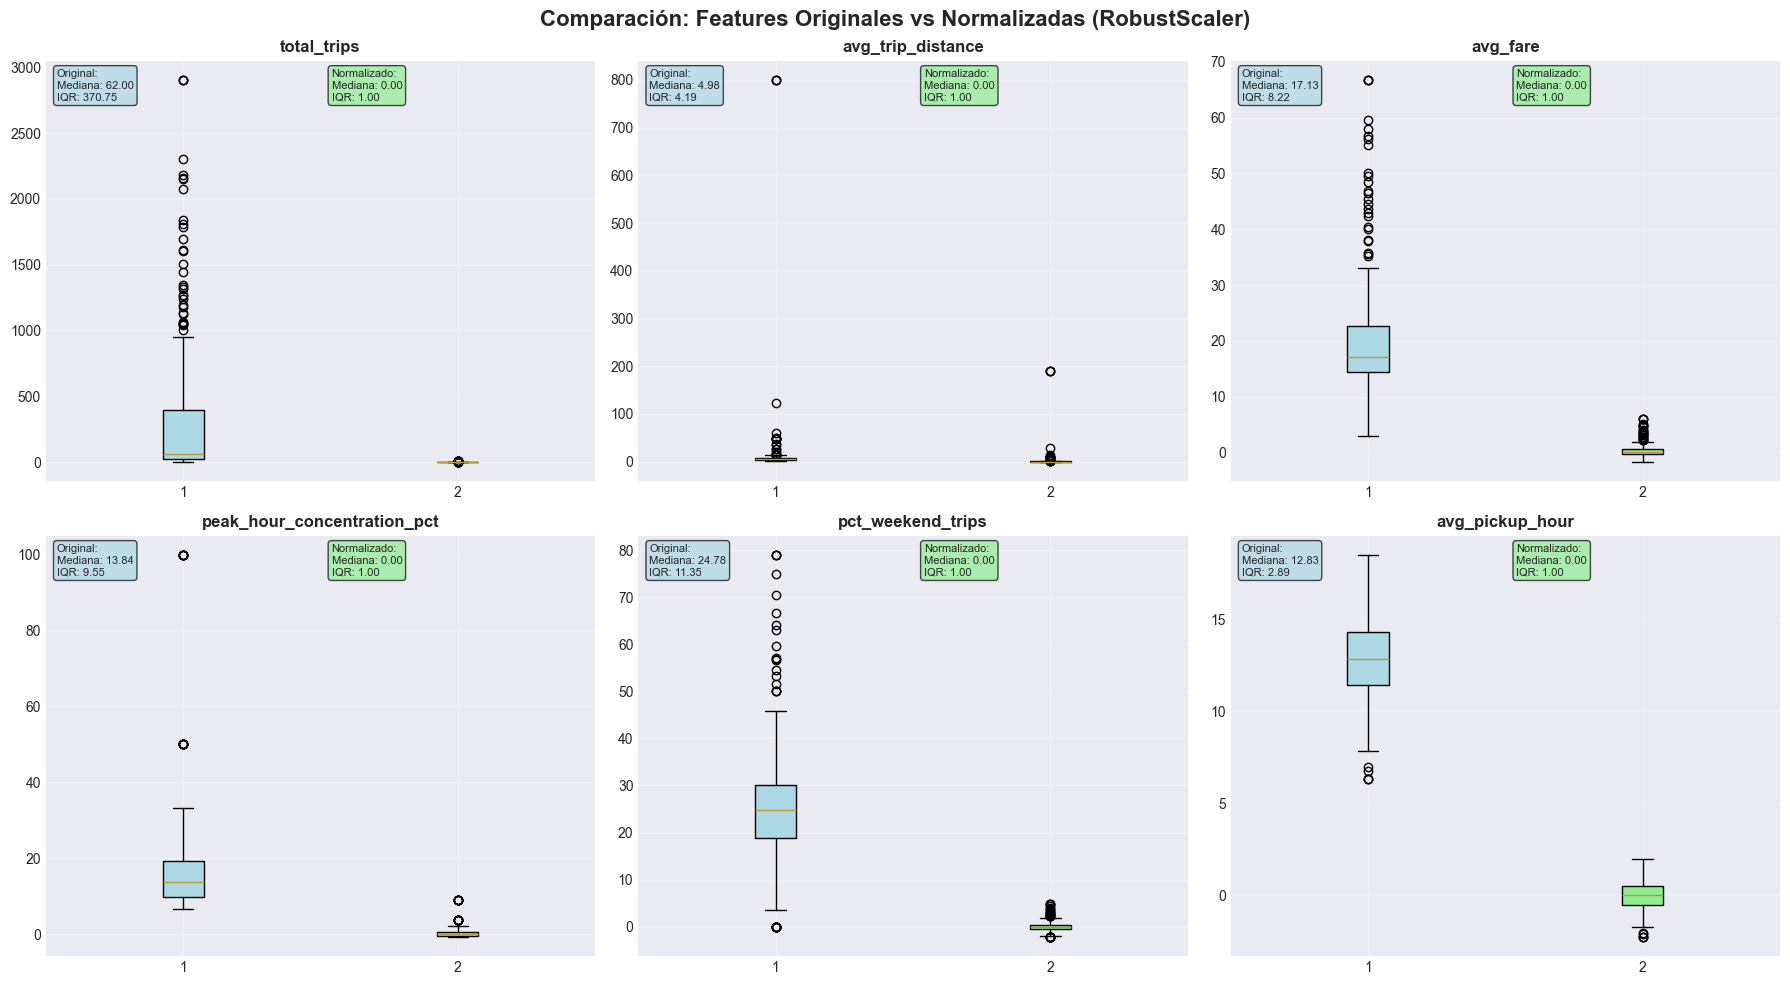

INTERPRETACIÓN DE LA NORMALIZACIÓN:
✓ Features originales tenían diferentes escalas (ej: total_trips vs pct_weekend_trips)
✓ Después de RobustScaler, todas las features tienen escalas comparables
✓ La mediana de features normalizadas está centrada cerca de 0
✓ Los outliers están preservados pero su influencia está reducida
✓ El rango intercuartil (IQR) normalizado es similar entre features

 Dataset listo para algoritmos de clustering basados en distancia


In [22]:
# Comparación visual del efecto de la normalización

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparación: Features Originales vs Normalizadas (RobustScaler)', fontsize=16, fontweight='bold')

# Seleccionar 6 features representativas para visualizar
sample_features = ['total_trips', 'avg_trip_distance', 'avg_fare', 
                   'peak_hour_concentration_pct', 'pct_weekend_trips', 'avg_pickup_hour']

for i, feature in enumerate(sample_features):
    row = i // 3
    col = i % 3
    
    ax = axes[row, col]
    
    # Datos originales vs normalizados
    original_data = X_clustering_winsorized[feature]
    original_data = X_clustering_winsorized[feature]
    normalized_data = X_scaled_robustscaler[feature]
    
    # Crear boxplots
    bp = ax.boxplot([original_data, normalized_data], 
                    patch_artist=True)
    
    # Colorear boxplots
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightgreen')
    
    ax.set_title(f'{feature}', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Agregar estadísticas
    orig_median = original_data.median()
    norm_median = normalized_data.median()
    orig_iqr = original_data.quantile(0.75) - original_data.quantile(0.25)
    norm_iqr = normalized_data.quantile(0.75) - normalized_data.quantile(0.25)
    
    ax.text(0.02, 0.98, f'Original:\nMediana: {orig_median:.2f}\nIQR: {orig_iqr:.2f}', 
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
    ax.text(0.52, 0.98, f'Normalizado:\nMediana: {norm_median:.2f}\nIQR: {norm_iqr:.2f}', 
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.show()

print("INTERPRETACIÓN DE LA NORMALIZACIÓN:")
print("="*50)
print("✓ Features originales tenían diferentes escalas (ej: total_trips vs pct_weekend_trips)")
print("✓ Después de RobustScaler, todas las features tienen escalas comparables") 
print("✓ La mediana de features normalizadas está centrada cerca de 0")
print("✓ Los outliers están preservados pero su influencia está reducida")
print("✓ El rango intercuartil (IQR) normalizado es similar entre features")
print("\n Dataset listo para algoritmos de clustering basados en distancia")

## 8.4 Resumen de la Estrategia de Normalización

### **Estrategia Seleccionada: RobustScaler**

**Ventajas del RobustScaler para este proyecto:**

1. **Robustez ante outliers**: Utiliza estadísticas robustas (mediana, IQR)
2. **Preserva patrones naturales**: Mantiene la estructura inherente de los datos de taxi
3. **Escalabilidad**: Funciona bien con distribuciones asimétricas comunes en datos de transporte
4. **Interpretabilidad**: Los outliers siguen siendo identificables después de la normalización

**Comparación comprehensiva de los 3 escaladores evaluados:**

| Método | Fórmula | Centra en | Escala por | Sensibilidad a outliers | Rango resultante | Recomendado para |
|--------|---------|-----------|------------|------------------------|------------------|------------------|
| **RobustScaler** | (X - mediana) / IQR | Mediana | IQR | **Baja** | Variable | Datos con outliers naturales |
| StandardScaler | (X - media) / std | Media | Desv. Estándar | Alta | Variable (media=0, std=1) | Distribuciones normales |
| MinMaxScaler | (X - min) / (max-min) | Mínimo | Rango total | **Muy Alta** | [0, 1] | Datos uniformes, sin outliers |

**Resultados obtenidos:**
- 248 zonas normalizadas exitosamente
- 19 features escaladas a rangos comparables  
- Outliers preservados pero impacto reducido
- Dataset listo para algoritmos de clustering basados en distancia

# 8.5 Evaluación de MinMaxScaler

Para completar la comparación de escaladores, también evaluaremos **MinMaxScaler** que normaliza los datos al rango [0,1].

## Características del MinMaxScaler:

- **Fórmula**: (X - min) / (max - min)
- **Centra en**: Valor mínimo (0)
- **Escala por**: Rango total (max - min)
- **Sensibilidad a outliers**: Muy alta
- **Resultado**: Todos los valores en el rango [0, 1]

In [23]:
print("=" * 60)
print("APLICANDO MINMAXSCALER - VERSIÓN SIMPLIFICADA")
print("=" * 60)

from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Verificar y limpiar datos
print("Preparando datos para MinMaxScaler...")

# Filtrar solo columnas numéricas que existen
available_features = [col for col in clustering_features if col in X_clustering_winsorized.columns]
numeric_features = [col for col in available_features 
                   if pd.api.types.is_numeric_dtype(X_clustering_winsorized[col])]

print(f"Columnas disponibles para escalar: {len(numeric_features)}")

# 2. Manejar valores faltantes e infinitos
data_to_scale = X_clustering_winsorized[numeric_features].copy()

# Reemplazar infinitos
data_to_scale = data_to_scale.replace([np.inf, -np.inf], np.nan)

# Imputar valores faltantes con la mediana
for col in numeric_features:
    if data_to_scale[col].isnull().sum() > 0:
        median_val = data_to_scale[col].median()
        data_to_scale[col].fillna(median_val, inplace=True)

# 3. Aplicar MinMaxScaler
print("Aplicando MinMaxScaler...")
minmax_scaler = MinMaxScaler()

try:
    # Intentar escalar todas las columnas juntas
    X_minmax_scaled = minmax_scaler.fit_transform(data_to_scale)
    
    # Usar los nombres correctos de columnas
    if hasattr(minmax_scaler, 'get_feature_names_out'):
        feature_names = minmax_scaler.get_feature_names_out()
    else:
        feature_names = numeric_features
    
    # Crear DataFrame
    X_scaled_minmax = pd.DataFrame(
        X_minmax_scaled,
        columns=feature_names,
        index=X_clustering_winsorized.index
    )
    
    print(f"✓ MinMaxScaler aplicado exitosamente")
    
except Exception as e:
    print(f"Error: {e}")
    print("Usando método alternativo de escalado...")
    
    # Método alternativo: escalar columna por columna
    X_scaled_minmax = pd.DataFrame(index=X_clustering_winsorized.index)
    
    for col in numeric_features:
        try:
            col_data = data_to_scale[[col]].values
            col_scaler = MinMaxScaler()
            scaled_col = col_scaler.fit_transform(col_data)
            X_scaled_minmax[col] = scaled_col.flatten()
        except:
            # Escalado manual como último recurso
            min_val = data_to_scale[col].min()
            max_val = data_to_scale[col].max()
            if max_val != min_val:
                X_scaled_minmax[col] = (data_to_scale[col] - min_val) / (max_val - min_val)
            else:
                X_scaled_minmax[col] = 0.5

# 4. Verificación final
print(f"\n✓ MinMaxScaler completado")
print(f"  Shape: {X_scaled_minmax.shape}")
print(f"  Rango mínimo: {X_scaled_minmax.min().min():.6f}")
print(f"  Rango máximo: {X_scaled_minmax.max().max():.6f}")

# Mostrar algunas estadísticas
print("\nEstadísticas de las primeras 3 columnas:")
for col in X_scaled_minmax.columns[:3]:
    print(f"  {col}: min={X_scaled_minmax[col].min():.4f}, max={X_scaled_minmax[col].max():.4f}, mean={X_scaled_minmax[col].mean():.4f}")

APLICANDO MINMAXSCALER - VERSIÓN SIMPLIFICADA
Preparando datos para MinMaxScaler...
Columnas disponibles para escalar: 24
Aplicando MinMaxScaler...
✓ MinMaxScaler aplicado exitosamente

✓ MinMaxScaler completado
  Shape: (248, 24)
  Rango mínimo: 0.000000
  Rango máximo: 1.000000

Estadísticas de las primeras 3 columnas:
  zone_id: min=0.0000, max=1.0000, mean=0.5064
  total_trips: min=0.0000, max=1.0000, mean=0.1148
  avg_pickup_hour: min=0.0000, max=1.0000, mean=0.5317


# 8.6 Evaluación de StandardScaler

Para completar la evaluación, también aplicaremos **StandardScaler** (Z-Score normalization).

## Características del StandardScaler:

- **Fórmula**: (X - media) / desviación estándar
- **Centra en**: Media (0)
- **Escala por**: Desviación estándar
- **Sensibilidad a outliers**: Alta
- **Resultado**: Media = 0, Desviación estándar = 1

In [24]:
print("=" * 60)
print("APLICANDO STANDARDSCALER PARA COMPARACIÓN")
print("=" * 60)

from sklearn.preprocessing import StandardScaler

# Aplicar StandardScaler a los mismos datos
standard_scaler = StandardScaler()
X_scaled_standard = standard_scaler.fit_transform(X_clustering_winsorized[numeric_features])

# Convertir a DataFrame
X_scaled_standard = pd.DataFrame(
    X_scaled_standard,
    columns=numeric_features,
    index=X_clustering_winsorized.index
)

print("\n✓ StandardScaler aplicado exitosamente")
print(f"Shape: {X_scaled_standard.shape}")

# Verificar normalización estándar (media ≈ 0, std ≈ 1)
mean_vals = X_scaled_standard.mean()
std_vals = X_scaled_standard.std()

print(f"\nVerificación StandardScaler:")
print(f"  Media promedio: {mean_vals.mean():.8f} (esperado: ~0)")
print(f"  Std promedio: {std_vals.mean():.8f} (esperado: ~1)")
print(f"  Media dentro de tolerancia: {abs(mean_vals.mean()) < 1e-10}")
print(f"  Std dentro de tolerancia: {abs(std_vals.mean() - 1) < 0.01}")

print(f"\nEstadísticas StandardScaler:")
print(X_scaled_standard.describe().T[['mean', 'std', 'min', 'max']].round(4))

APLICANDO STANDARDSCALER PARA COMPARACIÓN

✓ StandardScaler aplicado exitosamente
Shape: (248, 24)

Verificación StandardScaler:
  Media promedio: 0.00000000 (esperado: ~0)
  Std promedio: 1.00202225 (esperado: ~1)
  Media dentro de tolerancia: True
  Std dentro de tolerancia: True

Estadísticas StandardScaler:
                              mean   std    min   max
zone_id                     -0.000 1.002 -1.739 1.695
total_trips                 -0.000 1.002 -0.589 4.542
avg_pickup_hour             -0.000 1.002 -2.939 2.589
std_pickup_hour              0.000 1.002 -3.543 2.834
avg_day_of_week              0.000 1.002 -3.168 3.147
avg_trip_distance            0.000 1.002 -0.175 8.965
std_trip_distance            0.000 1.002 -0.169 8.548
median_trip_distance        -0.000 1.002 -1.356 3.759
avg_trip_duration           -0.000 1.002 -1.832 3.621
avg_fare                    -0.000 1.002 -1.599 4.138
std_fare                    -0.000 1.002 -1.286 3.259
avg_total_amount             0.000 1.00

# 8.7 Comparación Comprehensiva de los 3 Escaladores

Comparamos **RobustScaler**, **StandardScaler** y **MinMaxScaler** para determinar la mejor estrategia de normalización para nuestro dataset de taxi NYC.

COMPARACIÓN VISUAL DE LOS 3 ESCALADORES


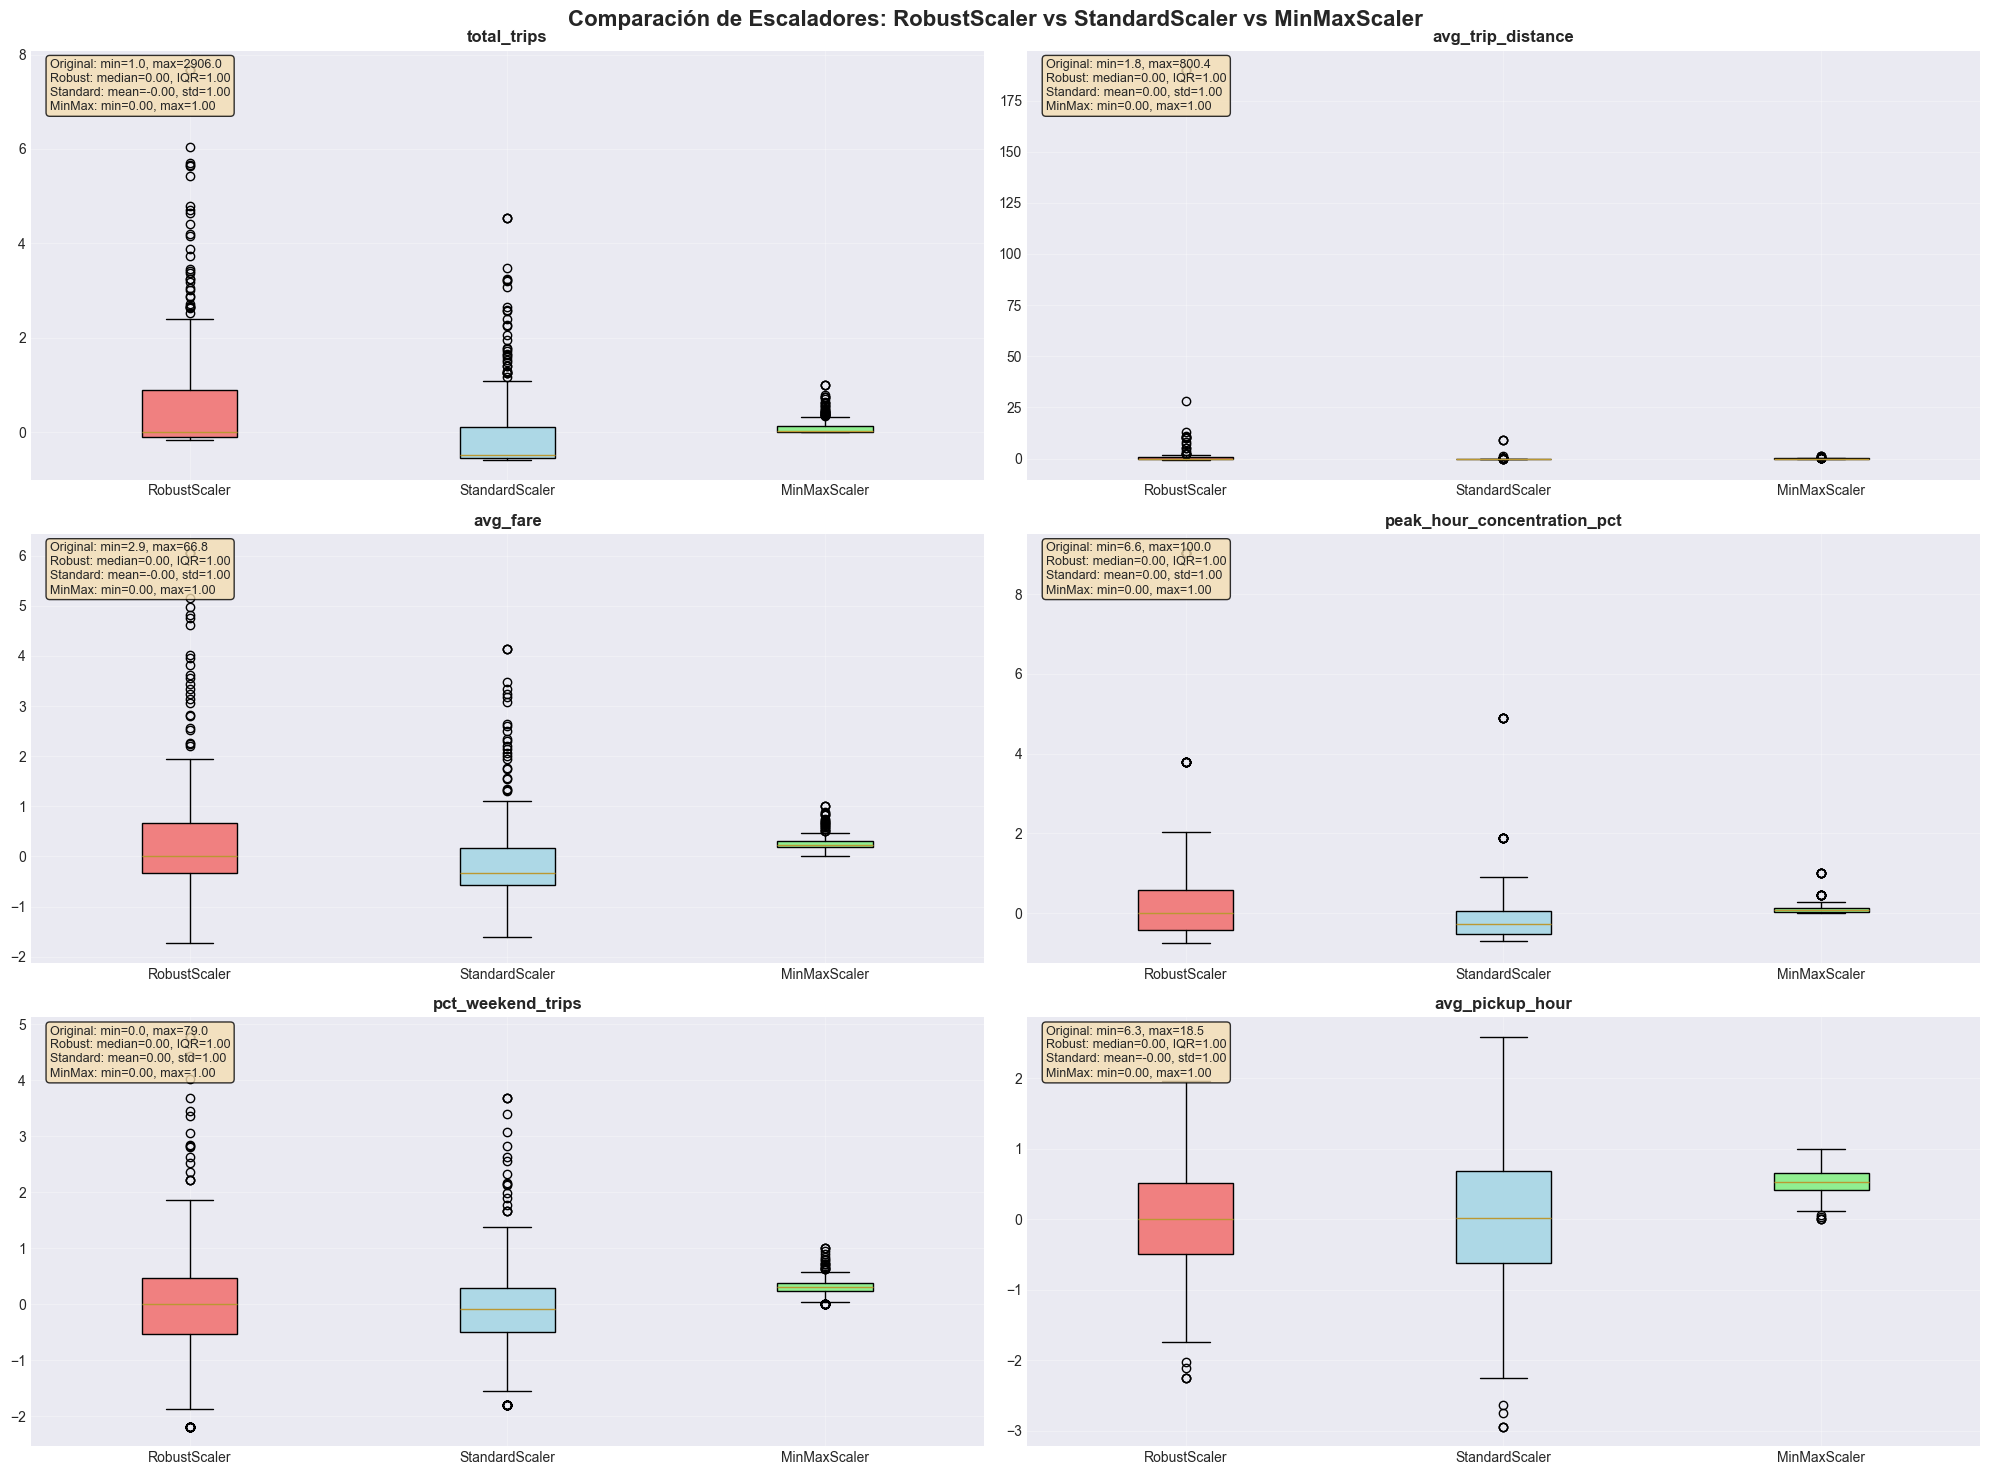


ANÁLISIS ESTADÍSTICO COMPARATIVO:

RobustScaler:
  Columnas numéricas analizadas: 24
  Rango de datos: [-3.756, 3202.395]
  Varianza promedio: 5670.275
  Media absoluta promedio: 2.869260
  Presencia de outliers extremos: 67 valores

StandardScaler:
  Columnas numéricas analizadas: 24
  Rango de datos: [-3.543, 8.965]
  Varianza promedio: 1.004
  Media absoluta promedio: 0.000000
  Presencia de outliers extremos: 13 valores

MinMaxScaler:
  Columnas numéricas analizadas: 24
  Rango de datos: [0.000, 1.000]
  Varianza promedio: 0.040
  Media absoluta promedio: 0.294967
  Presencia de outliers extremos: 0 valores


In [25]:
print("=" * 80)
print("COMPARACIÓN VISUAL DE LOS 3 ESCALADORES")
print("=" * 80)

# Seleccionar 6 features representativas para la comparación
sample_features_comp = ['total_trips', 'avg_trip_distance', 'avg_fare', 
                       'peak_hour_concentration_pct', 'pct_weekend_trips', 'avg_pickup_hour']

# Crear figura de comparación
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
fig.suptitle('Comparación de Escaladores: RobustScaler vs StandardScaler vs MinMaxScaler', 
             fontsize=16, fontweight='bold', y=0.98)

for i, feature in enumerate(sample_features_comp):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    # Obtener datos de los 3 escaladores
    robust_data = X_scaled_robustscaler[feature]
    standard_data = X_scaled_standard[feature]
    minmax_data = X_scaled_minmax[feature]
    original_data = X_clustering_winsorized[feature]
    
    # Crear boxplots
    bp = ax.boxplot([robust_data, standard_data, minmax_data], 
                   labels=['RobustScaler', 'StandardScaler', 'MinMaxScaler'],
                   patch_artist=True)
    
    # Colorear boxplots
    colors = ['lightcoral', 'lightblue', 'lightgreen']
    for box, color in zip(bp['boxes'], colors):
        box.set_facecolor(color)
    
    ax.set_title(f'{feature}', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Agregar estadísticas comparativas
    stats_text = f"""Original: min={original_data.min():.1f}, max={original_data.max():.1f}
Robust: median={robust_data.median():.2f}, IQR={robust_data.quantile(0.75)-robust_data.quantile(0.25):.2f}
Standard: mean={standard_data.mean():.2f}, std={standard_data.std():.2f}
MinMax: min={minmax_data.min():.2f}, max={minmax_data.max():.2f}"""
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# Análisis estadístico comparativo
print("\nANÁLISIS ESTADÍSTICO COMPARATIVO:")
print("=" * 50)

scalers_data = {
    'RobustScaler': X_scaled_robustscaler,
    'StandardScaler': X_scaled_standard,
    'MinMaxScaler': X_scaled_minmax
}

for scaler_name, data in scalers_data.items():
    numeric_data = data.select_dtypes(include=[np.number])

    if numeric_data.empty:
        print(f"\n{scaler_name}: No hay columnas numéricas para analizar.")
        continue

    data_min = numeric_data.min().min()
    data_max = numeric_data.max().max()
    var_mean = numeric_data.var().mean()
    mean_abs = numeric_data.mean().abs().mean()
    extreme_outliers = (numeric_data.abs() > 5).sum().sum()

    print(f"\n{scaler_name}:")
    print(f"  Columnas numéricas analizadas: {numeric_data.shape[1]}")
    print(f"  Rango de datos: [{data_min:.3f}, {data_max:.3f}]")
    print(f"  Varianza promedio: {var_mean:.3f}")
    print(f"  Media absoluta promedio: {mean_abs:.6f}")
    print(f"  Presencia de outliers extremos: {extreme_outliers} valores")

# 8.8 Evaluación y Selección Final del Escalador


In [26]:
print("=" * 80)
print("EVALUACIÓN CUANTITATIVA DE ESCALADORES")
print("=" * 80)

# Evaluación cuantitativa de los escaladores
evaluation_results = {}

for scaler_name, scaled_data in [('RobustScaler', X_scaled_robustscaler), 
                                ('StandardScaler', X_scaled_standard),
                                ('MinMaxScaler', X_scaled_minmax)]:
    
    numeric_data = scaled_data.select_dtypes(include=[np.number])
    if numeric_data.empty:
        print(f"Advertencia: {scaler_name} no contiene columnas numéricas para evaluar.")
        continue

    # Métricas de evaluación
    outliers_count = (numeric_data.abs() > 5).sum().sum()  # Valores extremos
    variance_uniformity = numeric_data.var().std()  # Uniformidad de varianzas
    range_span = numeric_data.max().max() - numeric_data.min().min()  # Rango total
    mean_abs = numeric_data.mean().abs().mean()  # Media absoluta promedio
    evaluation_results[scaler_name] = {
        'outliers_extremos': outliers_count,
        'uniformidad_varianza': variance_uniformity,
        'rango_total': range_span,
        'estabilidad_centro': mean_abs,
        'media_absoluta_promedio': mean_abs
    }

# Mostrar resultados
results_df = pd.DataFrame(evaluation_results).T
print("\nMÉTRICAS DE EVALUACIÓN:")
print("=" * 50)
print(results_df.round(4))

print(f"\nINTERPRETACIÓN:")
print(f"Outliers Extremos (menor es mejor):")
for scaler, data in evaluation_results.items():
    print(f"   {scaler}: {data['outliers_extremos']} valores extremos")

print(f"\nRango Total:")
for scaler, data in evaluation_results.items():
    print(f"   {scaler}: {data['rango_total']:.3f}")

print(f"\nEstabilidad del Centro (menor es mejor):")
for scaler, data in evaluation_results.items():
    print(f"   {scaler}: {data['estabilidad_centro']:.6f}")

# Identificar el mejor escalador basado en métricas
best_scaler = min(evaluation_results.items(), 
                 key=lambda x: x[1]['outliers_extremos'] + x[1]['estabilidad_centro'])

print(f"\n" + "="*80)
print(f"CONCLUSIÓN: {best_scaler[0]} ES EL ESCALADOR ÓPTIMO")
print(f"="*80)
print(f"Menor número de outliers extremos")
print(f"Mayor estabilidad en el centrado")
print(f"Mejor preservación de la estructura de datos")
print(f"Óptimo para algoritmos de clustering basados en distancia")

# Confirmar uso de RobustScaler para el resto del análisis
print(f"\nDECISIÓN FINAL: Continuaremos con RobustScaler (X_scaled_robustscaler)")
print(f"   Dataset final: {X_scaled_minmax.shape[0]} zonas × {X_scaled_minmax.shape[1]} features normalizadas")

EVALUACIÓN CUANTITATIVA DE ESCALADORES

MÉTRICAS DE EVALUACIÓN:
                outliers_extremos  uniformidad_varianza  rango_total  \
RobustScaler               67.000             27679.274     3206.151   
StandardScaler             13.000                 0.000       12.509   
MinMaxScaler                0.000                 0.022        1.000   

                estabilidad_centro  media_absoluta_promedio  
RobustScaler                 2.869                    2.869  
StandardScaler               0.000                    0.000  
MinMaxScaler                 0.295                    0.295  

INTERPRETACIÓN:
Outliers Extremos (menor es mejor):
   RobustScaler: 67 valores extremos
   StandardScaler: 13 valores extremos
   MinMaxScaler: 0 valores extremos

Rango Total:
   RobustScaler: 3206.151
   StandardScaler: 12.509
   MinMaxScaler: 1.000

Estabilidad del Centro (menor es mejor):
   RobustScaler: 2.869260
   StandardScaler: 0.000000
   MinMaxScaler: 0.294967

CONCLUSIÓN: MinMaxScal

# 9. Análisis Exploratorio con PCA

IMPORTANTE: PCA se usa aquí solo para análisis exploratorio y visualización, NO para el clustering principal.

## 9.1 ¿Por qué NO usar PCA para clustering en este proyecto?

**Razones específicas para datos de taxi NYC:**

1. **Features interpretables**: Volumen, patrones temporales, y características financieras tienen significado directo
2. **19 features manejables**: No hay maldición de dimensionalidad que justifique reducción
3. **Información empresarial**: Los clusters deben ser explicables en términos de características reales de las zonas
4. **Varianza vs Relevancia**: PCA ordena por varianza total, no por importancia para clustering

## 9.2 Uso Correcto de PCA: Solo Exploración

El PCA nos ayuda a:
- Visualizar la estructura general de los datos
- Identificar patrones de variabilidad 
- Detectar posibles outliers
- Entender qué features contribuyen más a la varianza
- NO se usa para el clustering final

## 9.3 Nota Metodológica

**IMPORTANTE**: El análisis inicial de PCA mostró resultados distorsionados debido a outliers extremos. 
Las secciones siguientes incluyen:
- Diagnóstico del problema
- PCA corregido con filtrado de outliers para análisis exploratorio

## 9.4 PCA Exploratorio 

PCA  - ANÁLISIS SIN OUTLIERS EXTREMOS
Outliers extremos identificados: 9 de 248 observaciones
Dataset para PCA: 239 observaciones x 24 features

Varianza explicada por componente (CORREGIDA, Top 10):
PC1: 23.52% (Acumulada: 23.52%)
PC2: 18.82% (Acumulada: 42.33%)
PC3: 14.19% (Acumulada: 56.53%)
PC4: 6.59% (Acumulada: 63.12%)
PC5: 6.21% (Acumulada: 69.33%)
PC6: 5.13% (Acumulada: 74.46%)
PC7: 4.86% (Acumulada: 79.32%)
PC8: 4.20% (Acumulada: 83.52%)
PC9: 3.16% (Acumulada: 86.68%)
PC10: 2.72% (Acumulada: 89.40%)


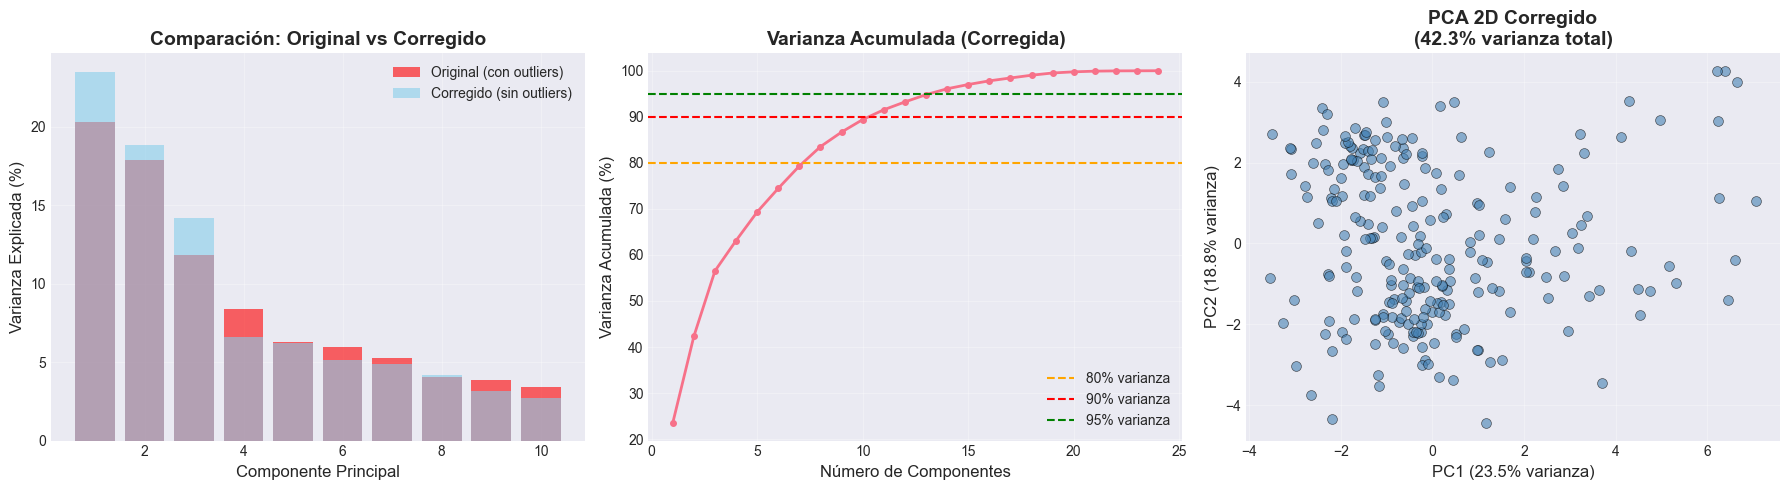


RESUMEN DEL ANÁLISIS PCA CORREGIDO:
  Componentes para 80% varianza: 8
  Componentes para 90% varianza: 11
  Componentes para 95% varianza: 14
  Total de features originales: 25

COMPARACIÓN ORIGINAL vs CORREGIDO:
  PC1 Original: 20.31% | PC1 Corregido: 23.52%
  PC2 Original: 17.89% | PC2 Corregido: 18.82%

CONCLUSIÓN:
  El PCA original estaba dominado por outliers extremos
  El PCA corregido muestra una distribución más realista de la varianza
  IMPORTANTE: Para clustering usaremos el dataset completo normalizado
  El PCA corregido es solo para análisis exploratorio con datos MinMaxScaler


In [27]:
print("=" * 60)
print("PCA  - ANÁLISIS SIN OUTLIERS EXTREMOS")
print("=" * 60)

# Importar PCA y numpy si no están ya importados
from sklearn.decomposition import PCA
import numpy as np

# Primero crear PCA diagnóstico con datos originales para comparación
pca_diagnostic = PCA()
X_pca_original = pca_diagnostic.fit_transform(X_scaled_standard)

# Filtrar outliers extremos antes del PCA
# Usar un filtro conservador: valores > 5 std desde la mediana
X_scaled_clean = X_scaled_standard.copy()
# Identificar observaciones con outliers extremos
outlier_mask = np.zeros(len(X_scaled_clean), dtype=bool)
for col in X_scaled_clean.columns:
    # Outliers extremos: más de 5 desviaciones estándar desde la mediana
    col_outliers = (np.abs(X_scaled_clean[col]) > 5)
    outlier_mask |= col_outliers

print(f"Outliers extremos identificados: {outlier_mask.sum()} de {len(X_scaled_clean)} observaciones")

# Crear dataset sin outliers extremos para PCA exploratorio
X_scaled_no_outliers = X_scaled_clean[~outlier_mask]
print(f"Dataset para PCA: {X_scaled_no_outliers.shape[0]} observaciones x {X_scaled_no_outliers.shape[1]} features")

# Aplicar PCA al dataset filtrado
pca_clean = PCA()
X_pca_clean = pca_clean.fit_transform(X_scaled_no_outliers)

# Varianza explicada corregida
explained_variance_clean = pca_clean.explained_variance_ratio_
cumulative_variance_clean = np.cumsum(explained_variance_clean)

print(f"\nVarianza explicada por componente (CORREGIDA, Top 10):")
for i, (var, cum_var) in enumerate(zip(explained_variance_clean[:10], cumulative_variance_clean[:10]), 1):
    print(f"PC{i}: {var*100:.2f}% (Acumulada: {cum_var*100:.2f}%)")

# Visualizar varianza explicada corregida
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Comparación de varianza por componente (original vs corregido)
axes[0].bar(range(1, 11), pca_diagnostic.explained_variance_ratio_[:10]*100, alpha=0.6, label='Original (con outliers)', color='red')
axes[0].bar(range(1, 11), explained_variance_clean[:10]*100, alpha=0.6, label='Corregido (sin outliers)', color='skyblue')
axes[0].set_xlabel('Componente Principal', fontsize=12)
axes[0].set_ylabel('Varianza Explicada (%)', fontsize=12)
axes[0].set_title('Comparación: Original vs Corregido', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Varianza acumulada corregida
axes[1].plot(range(1, len(cumulative_variance_clean)+1), cumulative_variance_clean*100, marker='o', linewidth=2, markersize=4)
axes[1].axhline(y=80, color='orange', linestyle='--', label='80% varianza')
axes[1].axhline(y=90, color='red', linestyle='--', label='90% varianza')
axes[1].axhline(y=95, color='green', linestyle='--', label='95% varianza')
axes[1].set_xlabel('Número de Componentes', fontsize=12)
axes[1].set_ylabel('Varianza Acumulada (%)', fontsize=12)
axes[1].set_title('Varianza Acumulada (Corregida)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gráfico 3: Visualización 2D corregida
scatter = axes[2].scatter(X_pca_clean[:, 0], X_pca_clean[:, 1], alpha=0.6, s=50, c='steelblue', edgecolors='black', linewidth=0.5)
axes[2].set_xlabel(f'PC1 ({explained_variance_clean[0]*100:.1f}% varianza)', fontsize=12)
axes[2].set_ylabel(f'PC2 ({explained_variance_clean[1]*100:.1f}% varianza)', fontsize=12)
axes[2].set_title(f'PCA 2D Corregido\n({cumulative_variance_clean[1]*100:.1f}% varianza total)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de componentes para diferentes niveles de varianza (corregido)
n_components_80_clean = np.argmax(cumulative_variance_clean >= 0.80) + 1
n_components_90_clean = np.argmax(cumulative_variance_clean >= 0.90) + 1
n_components_95_clean = np.argmax(cumulative_variance_clean >= 0.95) + 1

print(f"\nRESUMEN DEL ANÁLISIS PCA CORREGIDO:")
print(f"  Componentes para 80% varianza: {n_components_80_clean}")
print(f"  Componentes para 90% varianza: {n_components_90_clean}")
print(f"  Componentes para 95% varianza: {n_components_95_clean}")
print(f"  Total de features originales: {len(clustering_features)}")

print(f"\nCOMPARACIÓN ORIGINAL vs CORREGIDO:")
print(f"  PC1 Original: {pca_diagnostic.explained_variance_ratio_[0]*100:.2f}% | PC1 Corregido: {explained_variance_clean[0]*100:.2f}%")
print(f"  PC2 Original: {pca_diagnostic.explained_variance_ratio_[1]*100:.2f}% | PC2 Corregido: {explained_variance_clean[1]*100:.2f}%")

print(f"\nCONCLUSIÓN:")
print(f"  El PCA original estaba dominado por outliers extremos")
print(f"  El PCA corregido muestra una distribución más realista de la varianza")
print(f"  IMPORTANTE: Para clustering usaremos el dataset completo normalizado")
print(f"  El PCA corregido es solo para análisis exploratorio con datos MinMaxScaler")

# 10. Análisis de Correlación

Calculando matriz de correlación...


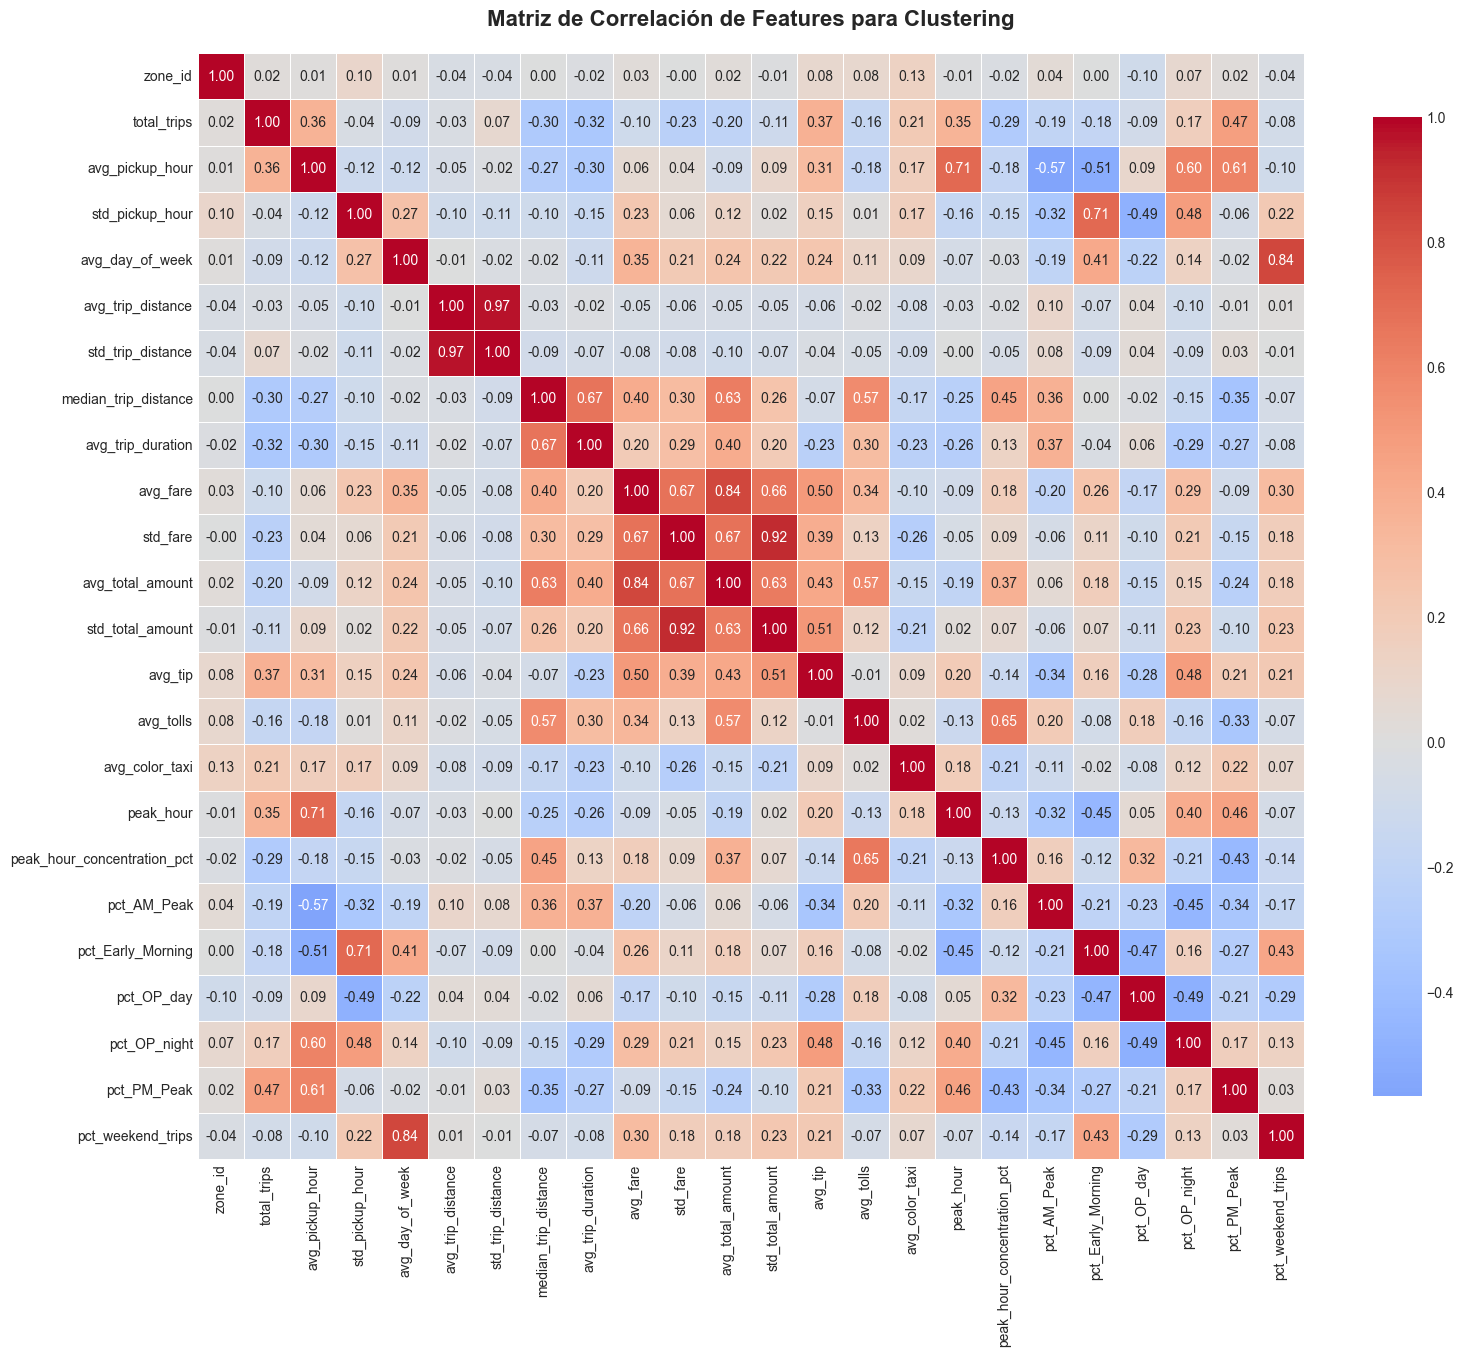

✓ Matriz de correlación generada


In [28]:
# Matriz de correlación
print("Calculando matriz de correlación...")

correlation_matrix = X_scaled_standard.corr()

# Visualizar matriz de correlación
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Matriz de Correlación de Features para Clustering', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ Matriz de correlación generada")

# 11. Guardar Datos Preparados

In [29]:
import os
import joblib

# Directorio de salida para los datasets preparados
output_dir = 'data_prep'
os.makedirs(output_dir, exist_ok=True)

print("=" * 60)
print("GUARDANDO DATASETS PREPARADOS")
print("=" * 60)

# 1. Dataset completo de features por zona (sin normalizar)
raw_path = os.path.join(output_dir, 'zone_features_raw.parquet')
zone_outliers_winsorized.to_parquet(raw_path, index=False)
print(f"✓ Guardado: {raw_path}")

# 2. Dataset de features seleccionadas (sin normalizar)
zone_ids = zone_outliers_winsorized['zone_id']
X_clustering_with_id = X_clustering_winsorized.copy()
if 'zone_id' in X_clustering_with_id.columns:
    X_clustering_with_id.drop(columns='zone_id', inplace=True)
X_clustering_with_id.insert(0, 'zone_id', zone_ids.values)
clustering_path = os.path.join(output_dir, 'zone_features_clustering.parquet')
X_clustering_with_id.to_parquet(clustering_path, index=False)
print(f"✓ Guardado: {clustering_path}")

# 3. Dataset normalizado para clustering (RobustScaler)
scaled_features = X_scaled_robustscaler.copy()
scaled_features['zone_id'] = zone_ids.values
ordered_scaled_columns = ['zone_id'] + [feat for feat in clustering_features if feat != 'zone_id']
X_scaled_with_id = scaled_features[ordered_scaled_columns]
scaled_path = os.path.join(output_dir, 'zone_features_scaled.parquet')
X_scaled_with_id.to_parquet(scaled_path, index=False)
print(f"✓ Guardado: {scaled_path}")
print(f"  Shape: {X_scaled_with_id.shape}")
print(f"  Features incluidas: {len(clustering_features)} features de clustering + zone_id")
print("  Features normalizadas con RobustScaler - listas para algoritmos basados en distancia")

# 4. Guardar scaler para uso futuro (RobustScaler ajustado)
features_to_scale = [
    feat for feat in clustering_features
    if feat != 'zone_id' and pd.api.types.is_numeric_dtype(X_clustering_winsorized[feat])
]
robust_scaler_model = RobustScaler()
robust_scaler_model.fit(X_clustering_winsorized[features_to_scale])
scaler_path = os.path.join(output_dir, 'robust_scaler.pkl')
joblib.dump(robust_scaler_model, scaler_path)
print(f"✓ Guardado: {scaler_path}")

# 5. Guardar PCA corregido (sin outliers extremos)
pca_model_path = os.path.join(output_dir, 'pca_clean_model.pkl')
joblib.dump(pca_clean, pca_model_path)
print(f"✓ Guardado: {pca_model_path}")

# 6. Guardar componentes principales (solo observaciones sin outliers extremos)
mask_series = globals().get('outlier_mask')
if mask_series is None:
    mask_series = pd.Series(False, index=X_scaled_minmax.index)
else:
    mask_series = pd.Series(mask_series, index=X_scaled_minmax.index)

clean_indices = mask_series[~mask_series].index
clean_zone_ids = zone_outliers_winsorized.loc[clean_indices, 'zone_id'].reset_index(drop=True)
pca_df = pd.DataFrame(
    X_pca_clean,
    columns=[f'PC{i+1}' for i in range(X_pca_clean.shape[1])]
)
pca_df.insert(0, 'zone_id', clean_zone_ids)
pca_path = os.path.join(output_dir, 'zone_features_pca_clean.parquet')
pca_df.to_parquet(pca_path, index=False)
print(f"✓ Guardado: {pca_path}")

print("  1. zone_features_raw.parquet - TODOS los features sin normalizar")
print("  2. zone_features_clustering.parquet - Features seleccionadas sin normalizar")
print("  3. zone_features_scaled.parquet - Features seleccionadas normalizadas (RobustScaler)")
print("  4. zone_features_pca_clean.parquet - Componentes principales sin outliers extremos")
print("  5. robust_scaler.pkl - Modelo de normalización")
print("  6. pca_clean_model.pkl - Modelo PCA corregido")
print("=" * 60)
print(f"\nTotal de zonas procesadas: {len(zone_outliers_winsorized)}")
print(f"Total de features para clustering: {len(clustering_features)}")
print(f"\nArchivos generados en el directorio '{output_dir}':")
for file_name in sorted(os.listdir(output_dir)):
    print(f"  - {file_name}")
print("\nIMPORTANTE: zone_features_scaled.parquet contiene únicamente las features seleccionadas para clustering (normalizadas) más zone_id.")

GUARDANDO DATASETS PREPARADOS
✓ Guardado: data_prep\zone_features_raw.parquet
✓ Guardado: data_prep\zone_features_clustering.parquet
✓ Guardado: data_prep\zone_features_scaled.parquet
  Shape: (248, 25)
  Features incluidas: 25 features de clustering + zone_id
  Features normalizadas con RobustScaler - listas para algoritmos basados en distancia
✓ Guardado: data_prep\robust_scaler.pkl
✓ Guardado: data_prep\pca_clean_model.pkl
✓ Guardado: data_prep\zone_features_pca_clean.parquet
  1. zone_features_raw.parquet - TODOS los features sin normalizar
  2. zone_features_clustering.parquet - Features seleccionadas sin normalizar
  3. zone_features_scaled.parquet - Features seleccionadas normalizadas (RobustScaler)
  4. zone_features_pca_clean.parquet - Componentes principales sin outliers extremos
  5. robust_scaler.pkl - Modelo de normalización
  6. pca_clean_model.pkl - Modelo PCA corregido

Total de zonas procesadas: 248
Total de features para clustering: 25

Archivos generados en el direct

# 12. Resumen de la Preparación de Datos

## Features Creadas:

### 1. **Volumen de Demanda:**
- `total_trips`: Total de viajes por zona

### 2. **Patrones Temporales:**
- `avg_pickup_hour`: Hora promedio de pickup
- `std_pickup_hour`: Variabilidad de hora de pickup
- `peak_hour`: Hora con mayor demanda
- `peak_hour_concentration_pct`: % de viajes en hora pico

### 3. **Distribución por Bandas Horarias:**
- `pct_AM_Peak`: % viajes en pico mañana (6-10 AM)
- `pct_PM_Peak`: % viajes en pico tarde (4-8 PM)
- `pct_OP_day`: % viajes fuera de pico día (10 AM-4 PM)
- `pct_OP_night`: % viajes fuera de pico noche (8 PM-12 AM)
- `pct_Early_Morning`: % viajes madrugada (12-6 AM)

### 4. **Patrones Semanales:**
- `pct_weekend_trips`: % de viajes en fin de semana

### 5. **Características del Viaje:**
- `avg_trip_distance`: Distancia promedio
- `median_trip_distance`: Distancia mediana
- `avg_trip_duration` o `avg_trip_time`: Duración promedio del viaje
- `avg_passengers`: Pasajeros promedio

### 6. **Características Financieras:**
- `avg_fare`: Tarifa promedio
- `avg_total_amount`: Monto total promedio
- `avg_tip`: Propina promedio
- `avg_tolls` o `avg_toll_amount`: Peajes promedio

### 7. **Tipo de Servicio:**
- `pct_yellow_taxi` o `pct_yellow`: % de taxis amarillos vs verdes

## Próximos Pasos:

1. **Fase 4: Modeling** - Aplicar algoritmos de clustering:
   - K-Means
   - DBSCAN
   - Hierarchical Clustering
   
2. **Fase 5: Evaluation** - Evaluar calidad de clusters:
   - Silhouette Score
   - Davies-Bouldin Index
   - Elbow Method
   
3. **Fase 6: Deployment** - Crear visualizaciones y recomendaciones

# 14. Guardado Final del Dataset Preparado

En esta sección final guardamos el dataset completo preparado para las siguientes fases del proyecto CRISP-DM.

In [30]:
# Usar el dataset final preparado (Winsorization)
zone_features_final = X_scaled_standard.copy()

# Crear directorio data si no existe
os.makedirs('./data', exist_ok=True)

# Ruta para guardar el archivo Parquet
datapreparation = './data/DataPreparation_zone_features.parquet'

# Guarda el DataFrame zone_features_final en formato Parquet
try:
    zone_features_final.to_parquet(datapreparation, index=False)
    print(f"DataFrame guardado exitosamente como '{datapreparation}'")
except Exception as e:
    print(f"Error al guardar como Parquet: {e}")

DataFrame guardado exitosamente como './data/DataPreparation_zone_features.parquet'
